# FAA Twitter Analysis for Safety Signals and Complaints

Team: Samantha Archie, Joel Atikemah, Lucas Huynh, Hetong Wang

This notebook will serve as the main working notebook for the project. We use tweets related to the FAA, air traffic control, staffing shortages, aviation safety, and related policy discussions to study whether social media can provide early signals of potential airline safety concerns and customer complaints.

### Table of contents

I. Loading in data  
II. First pass checks  
III. Cleaning the structured fields  
IV. Basic EDA on the structured columns  
V. Preprocessing the text column  
VI. Basic text analysis with spaCy  
VII. N-grams  
VIII. Co-occurrence analysis  
IX. TF-IDF representation  
X. Linear dimensionality reduction  
XI. Manifold learning  
XII. Clustering  
XIII. Topic modeling with LDA
XIV. Sentiment and emotion with a pretrained transformer  
XV. Neural topic modeling with BERTopic


In [1]:
from pathlib import Path
from urllib.parse import urlparse
import html
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 220)
pd.set_option('display.max_columns', 40)

c:\Users\atike\anaconda3\envs\uda_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## I. Loading in data

We begin with the raw scraped file and take a first look at the columns that came back from the scrape.

In [2]:
# read in the data

data_path = Path('2025-2026 FAA Tweets/tweets_updated.csv')
df_raw = pd.read_csv(data_path)

print(f'rows: {len(df_raw):,}')
print(f'columns: {len(df_raw.columns)}')
print(sorted(df_raw.columns.tolist()))

rows: 5,919
columns: 16
['author.profilePicture', 'bookmarkCount', 'createdAt', 'id', 'isPinned', 'isQuote', 'isReply', 'lang', 'likeCount', 'quoteCount', 'replyCount', 'retweetCount', 'source', 'text', 'url', 'viewCount']


In [3]:
df_raw.head(3)

,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isQuote,isPinned
0,1994856060495015968,https://x.com/Fly_Nashville/status/1994856060495015968,UPDATE NOV. 29 1:45 P.M.| The Federal Aviation Administration (FAA) has lifted the ground delay program for Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe trave...,Sat Nov 29 19:48:42 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,1,0,8,1,12214,2,NaN,en,False,True,False
1,2046575680339771798,https://x.com/HighWireTalk/status/2046575680339771798,"The FAA has a staffing crisis, a worsening safety record, and a new solution: recruit video gamers. \r\n\r\nWhen the application window opened at midnight on April 17, 6,000 applications came in within seven hours. T...",Tue Apr 21 13:04:00 +0000 2026,https://pbs.twimg.com/profile_images/1422666863738249223/08oKwaPG_normal.jpg,6,0,16,0,1284,1,NaN,en,False,NaN,False
2,1994780036230959188,https://x.com/Fly_Nashville/status/1994780036230959188,UPDATE | The Federal Aviation Administration (FAA) has lifted the ground stop for incoming flights to Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe travels! #B...,Sat Nov 29 14:46:36 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,4,0,15,1,11844,0,NaN,en,False,True,False


## II. First pass checks

Before cleaning anything, it helps to look at missingness, sparsity, duplicates, and a few basic distributions in the raw file.

In [4]:
def summarize_columns(frame):
    rows = []
    for col in frame.columns:
        series = frame[col]
        row = {
            'column': col,
            'dtype': str(series.dtype),
            'missing_count': int(series.isna().sum()),
            'missing_pct': round(100 * series.isna().mean(), 2),
            'n_unique': int(series.nunique(dropna=True))
        }
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            row['zero_pct'] = round(100 * (series == 0).mean(), 2)
        else:
            row['zero_pct'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['missing_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)


raw_column_summary = summarize_columns(df_raw)
raw_column_summary

,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,source,float64,5919,100.0,0,0.00
1,isQuote,object,5546,93.7,1,NaN
2,url,str,0,0.0,4309,NaN
3,id,int64,0,0.0,4308,0.00
4,text,str,0,0.0,4275,NaN
5,createdAt,str,0,0.0,4271,NaN
6,author.profilePicture,str,0,0.0,2900,NaN
7,viewCount,int64,0,0.0,1868,10.31
8,likeCount,int64,0,0.0,303,36.51
9,retweetCount,int64,0,0.0,171,62.68


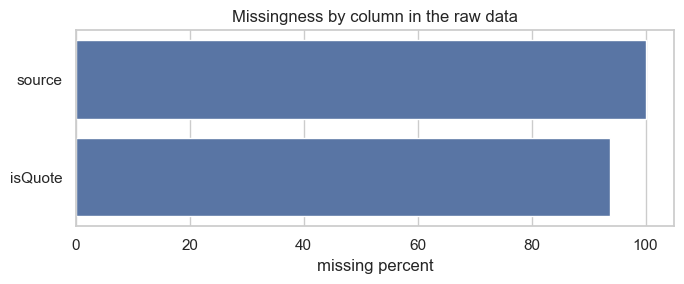

In [5]:
plt.figure(figsize=(7, 3))
missing_plot_df = raw_column_summary[raw_column_summary['missing_pct'] > 0]
sns.barplot(data=missing_plot_df, x='missing_pct', y='column')
plt.title('Missingness by column in the raw data')
plt.xlabel('missing percent')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [6]:
raw_duplicate_summary = pd.Series({
    'duplicate_ids': int(df_raw['id'].duplicated().sum()),
    'duplicate_urls': int(df_raw['url'].duplicated().sum()),
    'duplicate_texts': int(df_raw['text'].duplicated().sum()),
    'fully_duplicated_rows': int(df_raw.duplicated().sum())
})

raw_duplicate_summary

duplicate_ids            1611
duplicate_urls           1610
duplicate_texts          1644
fully_duplicated_rows    1436
dtype: int64

The duplicate counts are large enough that we should define a single working version of each tweet. For the rest of the notebook, we deduplicate by tweet ID and keep the row with the richest engagement snapshot.

In [7]:
raw_dates = pd.to_datetime(
    df_raw['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)

print('date range:')
print(raw_dates.min())
print(raw_dates.max())
print()
print('tweets by year:')
print(raw_dates.dt.year.value_counts().sort_index())
print()
print('language counts:')
print(df_raw['lang'].value_counts(dropna=False))

date range:
2008-11-18 22:18:30+00:00
2026-04-21 15:40:45+00:00

tweets by year:
createdAt
2008       1
2009       1
2010       1
2011       7
2012      30
2013      28
2014      72
2015      64
2016      51
2017      55
2018      35
2019     169
2020       2
2021      13
2022      72
2023     296
2024     141
2025    1766
2026    3115
Name: count, dtype: int64

language counts:
lang
en    5919
Name: count, dtype: int64


## III. Cleaning the structured fields

Now we clean a few of the structured columns. In particular, we parse the timestamps, derive an author handle from the tweet URL, fill the boolean indicator columns, drop a few fields we probably will not use directly, and deduplicate by tweet ID.

In [8]:
def extract_author_handle(url):
    parts = [part for part in urlparse(str(url)).path.split('/') if part]
    return parts[0] if parts else np.nan


engagement_cols = ['retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'bookmarkCount']


df = df_raw.copy()
df['createdAt'] = pd.to_datetime(
    df['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)
df['author_handle'] = df['url'].map(extract_author_handle)

for col in ['isReply', 'isQuote', 'isPinned']:
    df[col] = df[col].where(df[col].notna(), False).astype(bool)

df = (df
      .sort_values(['id'] + engagement_cols)
      .drop_duplicates(subset='id', keep='last')
      .drop(columns=['url', 'author.profilePicture', 'source'])
      .copy())

df['date'] = df['createdAt'].dt.date
df['year'] = df['createdAt'].dt.year
df['year_month'] = df['createdAt'].dt.strftime('%Y-%m')
df['hour'] = df['createdAt'].dt.hour

cleaning_summary = pd.Series({
    'raw_rows': len(df_raw),
    'rows_after_dedup_by_id': len(df),
    'rows_removed_as_duplicate_ids': len(df_raw) - len(df),
    'date_min': df['createdAt'].min(),
    'date_max': df['createdAt'].max(),
    'unique_authors': df['author_handle'].nunique()
})

cleaning_summary

raw_rows                                              5919
rows_after_dedup_by_id                                4308
rows_removed_as_duplicate_ids                         1611
date_min                         2008-11-18 22:18:30+00:00
date_max                         2026-04-21 15:40:45+00:00
unique_authors                                        2965
dtype: object

In [9]:
clean_column_summary = summarize_columns(df)
clean_column_summary

,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,id,int64,0,0.0,4308,0.00
1,text,str,0,0.0,4275,NaN
2,createdAt,"datetime64[us, UTC]",0,0.0,4271,NaN
3,author_handle,str,0,0.0,2965,NaN
4,viewCount,int64,0,0.0,1768,14.16
5,date,object,0,0.0,764,NaN
6,likeCount,int64,0,0.0,293,44.36
7,retweetCount,int64,0,0.0,169,62.95
8,replyCount,int64,0,0.0,115,68.55
9,year_month,str,0,0.0,111,NaN


## IV. Basic EDA on the structured columns

After deduplicating the tweets and dropping a few unused fields, we can look at who is posting, when the tweets appear, and how engagement is distributed across the sample.

In [94]:
print('tweets by year:')
print(df['year'].value_counts().sort_index())

tweets by year:
year
2008       1
2009       1
2010       1
2011       7
2012      30
2013      28
2014      72
2015      64
2016      51
2017      55
2018      35
2019     169
2020       2
2021      13
2022      72
2023     291
2024     139
2025    1629
2026    1648
Name: count, dtype: int64


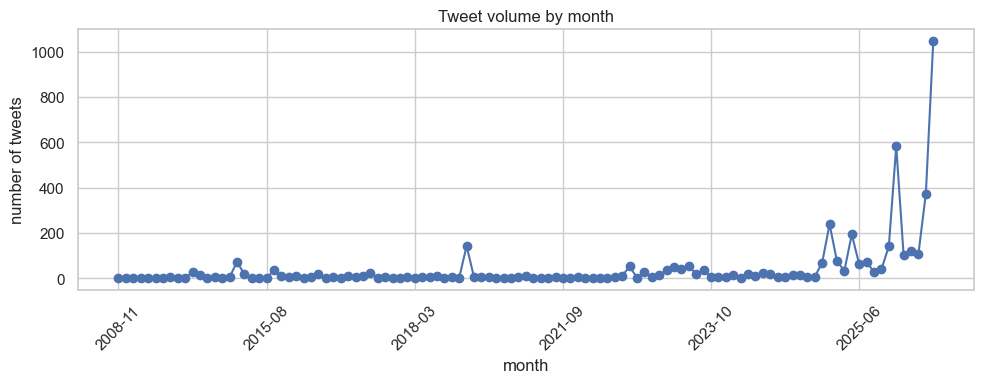

In [95]:
monthly_counts = df['year_month'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
monthly_counts.plot(marker='o')
plt.title('Tweet volume by month')
plt.xlabel('month')
plt.ylabel('number of tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
for col in ['lang', 'isReply', 'isQuote']:
    print(col)
    counts = df[col].value_counts(dropna=False)
    shares = (100 * df[col].value_counts(dropna=False, normalize=True)).round(2)
    display(pd.DataFrame({
        'count': counts,
        'share_pct': shares
    }))
    print()

lang


,count,share_pct
lang,,
en,4308,100.0



isReply


,count,share_pct
isReply,,
False,3731,86.61
True,577,13.39



isQuote


,count,share_pct
isQuote,,
False,4042,93.83
True,266,6.17


In [97]:
top_authors = df['author_handle'].value_counts().head(15)

top_authors

author_handle
grok               104
ATCAlerts           97
FAASafetyBrief      34
FAANews             23
ATCupdates          22
davidshepardson     18
AirlineHub1         18
P4HReform           17
HypeAviation        16
AviationWeek        16
business            13
petemuntean         13
CBSNews             12
NewsNation          12
ByERussell          12
Name: count, dtype: int64

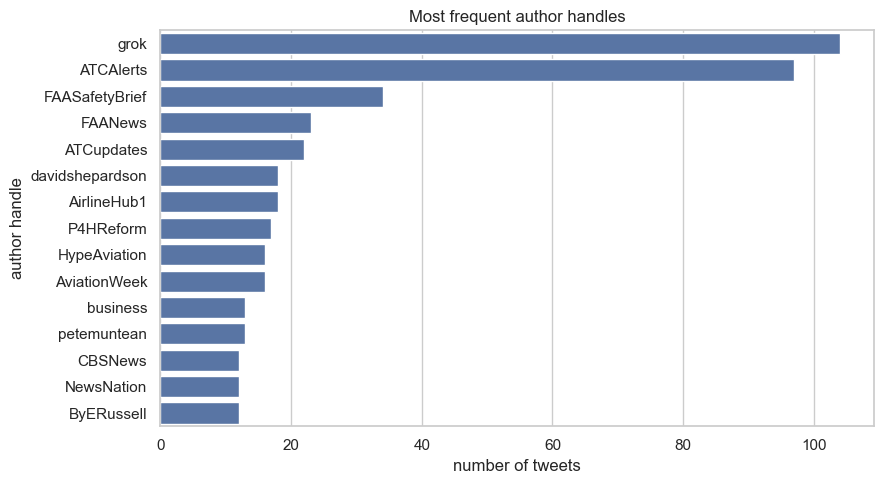

In [98]:
plt.figure(figsize=(9, 5))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title('Most frequent author handles')
plt.xlabel('number of tweets')
plt.ylabel('author handle')
plt.tight_layout()
plt.show()

In [99]:
reply_quote_summary = pd.DataFrame({
    'tweet_count': [
        len(df),
        int(df['isReply'].sum()),
        int(df['isQuote'].sum())
    ],
    'share_of_tweets': [
        1.0,
        df['isReply'].mean(),
        df['isQuote'].mean()
    ],
    'mean_views': [
        df['viewCount'].mean(),
        df.loc[df['isReply'], 'viewCount'].mean(),
        df.loc[df['isQuote'], 'viewCount'].mean()
    ],
    'median_views': [
        df['viewCount'].median(),
        df.loc[df['isReply'], 'viewCount'].median(),
        df.loc[df['isQuote'], 'viewCount'].median()
    ],
    'mean_likes': [
        df['likeCount'].mean(),
        df.loc[df['isReply'], 'likeCount'].mean(),
        df.loc[df['isQuote'], 'likeCount'].mean()
    ],
    'median_likes': [
        df['likeCount'].median(),
        df.loc[df['isReply'], 'likeCount'].median(),
        df.loc[df['isQuote'], 'likeCount'].median()
    ],
    'mean_retweets': [
        df['retweetCount'].mean(),
        df.loc[df['isReply'], 'retweetCount'].mean(),
        df.loc[df['isQuote'], 'retweetCount'].mean()
    ],
    'median_retweets': [
        df['retweetCount'].median(),
        df.loc[df['isReply'], 'retweetCount'].median(),
        df.loc[df['isQuote'], 'retweetCount'].median()
    ]
}, index=['all_tweets', 'replies', 'quotes']).round(2)

reply_quote_summary

,tweet_count,share_of_tweets,mean_views,median_views,mean_likes,median_likes,mean_retweets,median_retweets
all_tweets,4308,1.00,18337.81,153.5,93.32,1.0,20.76,0.0
replies,577,0.13,4326.91,79.0,46.63,1.0,5.85,0.0
quotes,266,0.06,151862.94,376.0,492.22,2.0,107.61,0.0


In [100]:
engagement_summary = pd.DataFrame({
    'mean': df[engagement_cols].mean(),
    'median': df[engagement_cols].median(),
    'std': df[engagement_cols].std(),
    'pct_zero': (100 * (df[engagement_cols] == 0).mean()),
    'max': df[engagement_cols].max()
}).round(2)

engagement_summary

,mean,median,std,pct_zero,max
retweetCount,20.76,0.0,353.22,62.95,20211
replyCount,8.59,0.0,172.14,68.55,9518
likeCount,93.32,1.0,1611.82,44.36,90211
quoteCount,2.35,0.0,48.83,84.70,2618
viewCount,18337.81,153.5,567652.51,14.16,36077248
bookmarkCount,6.96,0.0,176.99,81.13,10455


The mean-median gaps are fairly large for several engagement variables, which is a reminder that the distributions are highly skewed. That is one reason the later parts of the project will often rely on log transforms, medians, and other more robust summaries.

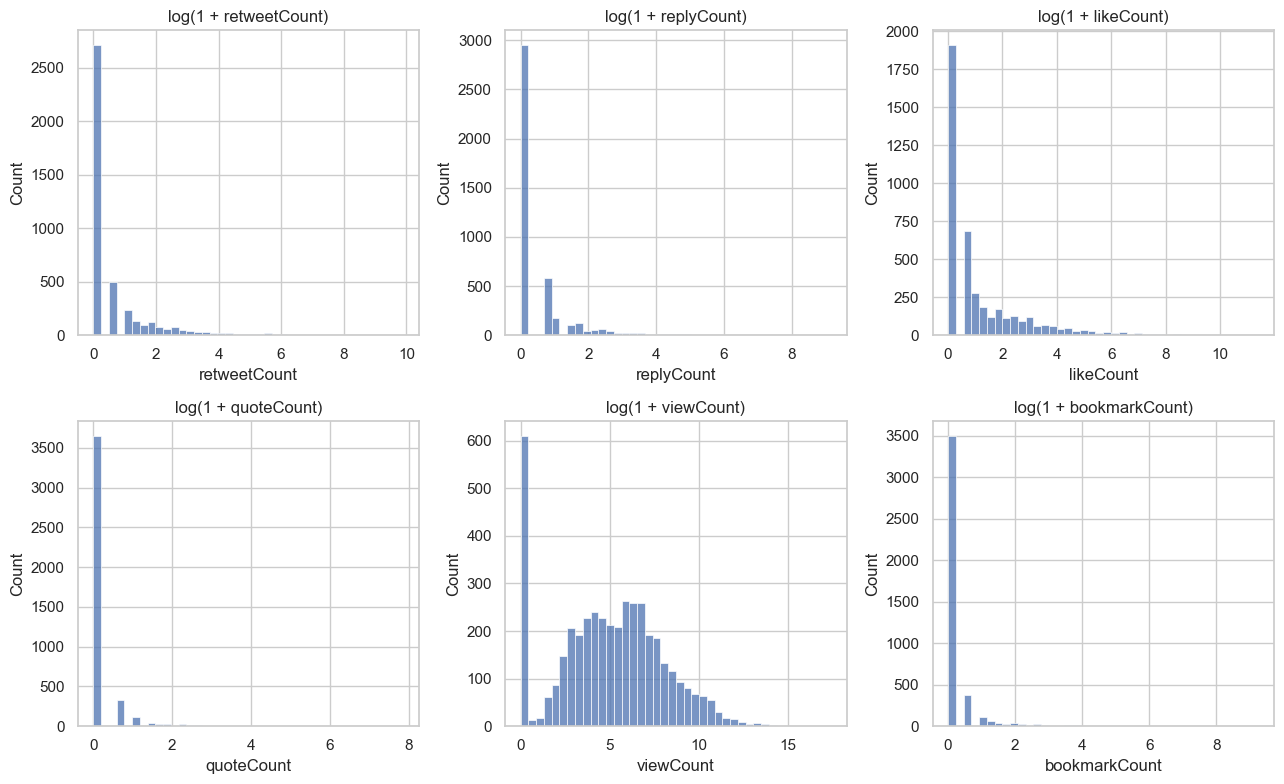

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, col in zip(axes, engagement_cols):
    sns.histplot(np.log1p(df[col]), bins=40, ax=ax)
    ax.set_title(f'log(1 + {col})')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [102]:
# look at a few of the highest-engagement tweets

df.sort_values('viewCount', ascending=False)[[
    'createdAt', 'author_handle', 'viewCount', 'likeCount', 'retweetCount', 'replyCount', 'text'
]].head(10)

,createdAt,author_handle,viewCount,likeCount,retweetCount,replyCount,text
625,2025-02-18 01:12:17+00:00,SecDuffy,36077248,90211,20211,9518,"Mayor Pete failed for four years to address the air traffic controller shortage and upgrade our outdated, World War II-era air traffic control system. In less than four weeks, we have already begun the process and ar..."
2251,2026-04-15 15:49:07+00:00,CBSNews,7575808,38174,3845,642,"Two pilots appeared to make meowing noises and dog barks as they communicated with each other before air traffic control at Ronald Reagan Washington National Airport called them out on Sunday.\r\n\r\n""You guys, you n..."
3731,2026-04-15 17:52:49+00:00,TranspoPolicy,3883363,1158,81,54,"America's skies need an upgrade.\r\nThe FAA has already made significant progress, but much more work remains to modernize air traffic control. https://t.co/3d4ElhUUtZ"
4728,2025-01-30 22:01:06+00:00,RBReich,1692566,27289,8390,3927,"To recap, Trump:\r\n\r\n-Forced out the FAA chief at Musk's insistence\r\n-Imposed a hiring freeze that reportedly included air traffic controllers\r\n-Fired the TSA head and gutted a key aviation safety committee\r\..."
1408,2025-02-01 03:20:51+00:00,ElTiranistas,1690382,7339,933,483,@DefiyantlyFree And the air traffic control shortage of employees started all the way back in the Obama administration. There's actually been a couple really good white papers written about it. It's been a thing for ...
4560,2026-03-23 10:49:33+00:00,FoxNews,1378623,2185,431,210,LISTEN: Air traffic control audio is released from the deadly runway collision at LaGuardia Airport.\r\n\r\nTwo pilots were killed and dozens of passengers were injured after an Air Canada jet collided with a fire tr...
4411,2026-03-23 12:16:09+00:00,Breaking911,990343,4699,999,96,"🚨 BREAKING: Just hours after a deadly crash at LaGuardia airport, the FAA has issued a ground stop at Newark Liberty International Airport after reports that one of the air traffic control towers was evacuated.\r\n\r..."
5672,2026-03-23 08:10:36+00:00,juliamacfarlane,938748,6992,1815,503,"If FAA staffing shortages turn out to be a key aspect of this horrible tragedy, remember that @elonmusk\r\n and his “Doge” department fired hundreds of FAA staffers last year - including safety workers, and even trie..."
523,2025-10-26 16:34:59+00:00,KTLA,873463,812,345,123,"#BREAKING: A staffing shortage in Southern California’s airspace triggered a ground stop affecting Los Angeles International Airport flights on Sunday morning, the FAA said. Details: https://t.co/HRtsDX2lex https://t..."
1956,2025-11-06 02:42:34+00:00,AmericanAir,861605,2709,587,159,"Due to the ongoing government shutdown and nationwide air traffic control staffing shortages, the FAA has directed airlines to reduce flight schedules to maintain safe airspace operations starting Friday, Nov. 7.\r\n..."


In [103]:
engagement_by_theme = (
    df.groupby("plot_theme")[["viewCount", "likeCount", "retweetCount", "replyCount"]]
    .median()
    .sort_values("viewCount", ascending=False)
)

engagement_by_theme

,viewCount,likeCount,retweetCount,replyCount
plot_theme,,,,
operations_disruption,428.0,1.0,0.0,0.0
other,358.0,1.0,0.0,0.0
military_drone,253.0,1.0,0.0,0.0
airport_incident,148.0,1.0,0.0,0.0
safety_oversight,140.0,1.0,0.0,0.0
airline_complaints,103.5,1.0,0.0,0.0
atc_staffing,81.0,1.0,0.0,0.0


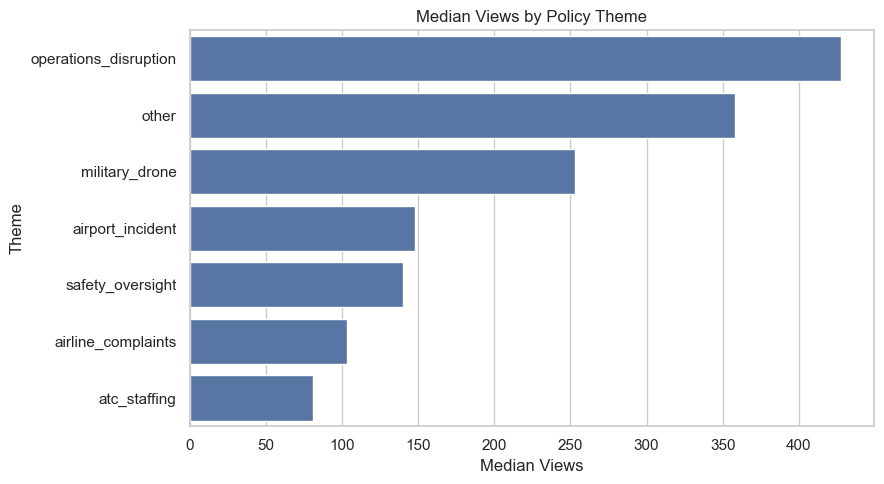

In [104]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=engagement_by_theme["viewCount"],
    y=engagement_by_theme.index
)

plt.title("Median Views by Policy Theme")
plt.xlabel("Median Views")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()

We wanted to answer which issues get the public's attention

## V. Preprocessing the text column

For the text, we keep two versions:

- `text_clean`: a lightly normalized version of the original tweet text
- `text_lemma`: a lemmatized version that should be convenient for later n-grams, topic modeling, dimensionality reduction, and clustering

The basic cleaning below removes URLs and mentions, keeps hashtag words, lowercases, normalizes whitespace, preserves apostrophes so negation is not lost too early, and strips a few scrape-specific news-card artifacts that showed up in the updated pull.

In [19]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#(\w+)')
extra_space_pattern = re.compile(r'\s+')
non_text_pattern = re.compile(r"[^a-z0-9'\s]")
artifact_pattern = re.compile(r'\b(?:click|image|read|story)\b')


def basic_clean(text):
    text = html.unescape(str(text))
    text = text.replace('\n', ' ')
    text = text.replace('’', "'")
    text = url_pattern.sub(' ', text)
    text = hashtag_pattern.sub(r' \1 ', text)
    text = mention_pattern.sub(' ', text)
    text = text.lower()
    text = non_text_pattern.sub(' ', text)
    text = artifact_pattern.sub(' ', text)
    text = extra_space_pattern.sub(' ', text).strip()
    return text

In [20]:
df['text_clean'] = df['text'].map(basic_clean)
df[['text', 'text_clean']].head(8)

,text,text_clean
1771,Wednesday's Choose Your News Stories: 1) Squeaky The Kangaroo Lady 2) Air Traffic Control Shortage 3) Tony Alamo Investigation,wednesday's choose your news stories 1 squeaky the kangaroo lady 2 air traffic control shortage 3 tony alamo investigation
4265,"U.S. Travel Endorses Much-Needed FAA Reauthorization Legislation: \r\n\t\tBill Will Modernize Air Traffic Control, Im.. http://tr.im/tHd4",u s travel endorses much needed faa reauthorization legislation bill will modernize air traffic control im
4002,Safety Culture News Reason Foundation - Air Traffic Control Reform Newsletter #75: FAA's Chronic Funding Problem; ... http://bit.ly/bp7LGc,safety culture news reason foundation air traffic control reform newsletter 75 faa's chronic funding problem
4324,Schumer: New Air Traffic Control System Would Cut Delays at Local ...: FAA legislation introduced today includes... http://bit.ly/b6xyyB,schumer new air traffic control system would cut delays at local faa legislation introduced today includes
1913,Delayed 35 min. Staff shortage at Barcelona air traffic control. Lazy paella munching greasy scum bags,delayed 35 min staff shortage at barcelona air traffic control lazy paella munching greasy scum bags
3940,Air Traffic Control Reform Newsletter #85: In this issue:\r\nFAA controller workforce problems\r\nThe LightSquared GPS... http://bit.ly/nB5Gun,air traffic control reform newsletter 85 in this issue faa controller workforce problems the lightsquared gps
3902,RT @FlynKangaroo JetBlue calls for air traffic control reform - Reuters http://t.co/5JTV4Abt #aviation #flying #faa,rt jetblue calls for air traffic control reform reuters aviation flying faa
1900,delhi24X7 ATC staff shortage at IGI Airport: There is a shortage of air traffic control officers (ATCO... http://t.co/v82jr9Tw delhi24X7,delhi24x7 atc staff shortage at igi airport there is a shortage of air traffic control officers atco delhi24x7


The preprocessing demos in class use spaCy lemmatization, so we follow that same general pattern here.

In [21]:
# lemmatize the cleaned text

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def lemmatize_texts(texts, batch_size=64):
    docs = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        tokens = [token.lemma_ for token in doc if not token.is_space and not token.is_punct]
        docs.append(' '.join(tokens))
    return docs


df['text_lemma'] = lemmatize_texts(df['text_clean'].tolist())
df['n_tokens_clean'] = df['text_clean'].str.split().str.len()
df['n_tokens_lemma'] = df['text_lemma'].str.split().str.len()

100%|██████████| 4308/4308 [00:50<00:00, 85.57it/s] 


In [22]:
df[['text', 'text_clean', 'text_lemma']].sample(5, random_state=0)

,text,text_clean,text_lemma
1325,"So perfectly Musk-Trump. We have a long-standing shortage of Air Traffic Control's, so they urged the ones we have to QUIT. The Clueless Brothers in Action. \r\n\r\nAir traffic controllers were initially offered buyo...",so perfectly musk trump we have a long standing shortage of air traffic control's so they urged the ones we have to quit the clueless brothers in action air traffic controllers were initially offered buyouts and told...,so perfectly musk trump we have a long stand shortage of air traffic control 's so they urge the one we have to quit the clueless brother in action air traffic controller be initially offer buyout and tell to conside...
5382,"The post likely refers to a major winter storm causing over 8,000 flight cancellations across the US on Jan 26, 2026, per reports from FAA and news outlets like Fox and CNN. No official nationwide grounding, airspace...",the post likely refers to a major winter storm causing over 8 000 flight cancellations across the us on jan 26 2026 per reports from faa and news outlets like fox and cnn no official nationwide grounding airspace clo...,the post likely refer to a major winter storm cause over 8 000 flight cancellation across the us on jan 26 2026 per report from faa and news outlet like fox and cnn no official nationwide ground airspace closure or n...
5896,🚨 Russia suspected of jamming GPS for an EU leader’s plane ✈️⚠️ International travel under threat? \r\n\r\nGeopolitics meets aviation safety. \r\n\r\n#Russia #GPSJamming #EU #AviationSecurity #Putin #Trump https://t....,russia suspected of jamming gps for an eu leader's plane international travel under threat geopolitics meets aviation safety russia gpsjamming eu aviationsecurity putin trump,russia suspect of jam gps for an eu leader 's plane international travel under threat geopolitic meet aviation safety russia gpsjamme eu aviationsecurity putin trump
1659,BREAKING: *FAA HALTS FLIGHTS INTO N.Y.'S LAGUARDIA ON AIR TRAFFIC CONTROL STAFF SHORTAGE.\r\nThey all heard about the #BTT airdrops and went out to buy #TRON,breaking faa halts flights into n y 's laguardia on air traffic control staff shortage they all heard about the btt airdrops and went out to buy tron,break faa halt flight into n y 's laguardia on air traffic control staff shortage they all hear about the btt airdrop and go out to buy tron
5601,FAA flooded with complaints over shrinking airline seats: https://t.co/eoa8xwOC37,faa flooded with complaints over shrinking airline seats,faa flood with complaint over shrink airline seat


In [23]:
df[['n_tokens_clean', 'n_tokens_lemma']].describe().round(2)

,n_tokens_clean,n_tokens_lemma
count,4308.00,4308.00
mean,32.78,33.27
std,37.90,38.55
min,2.00,2.00
25%,16.00,16.00
50%,27.00,27.00
75%,39.00,40.00
max,1289.00,1315.00


## VI. Basic text analysis with spaCy

The spaCy demos in class start by inspecting how the parser sees an individual document, so we do the same here with one tweet. After that, we move to simple corpus-level summaries such as parts of speech and named entities.

In [24]:
nlp_full = spacy.load('en_core_web_sm')

example_text = df.sort_values('viewCount', ascending=False)['text'].iloc[0]
parsed_example = nlp_full(example_text)

pd.DataFrame([{
    'token': token.text,
    'lemma': token.lemma_,
    'pos': token.pos_,
    'entity_type': token.ent_type_
} for token in parsed_example]).head(30)

,token,lemma,pos,entity_type
0,Mayor,Mayor,PROPN,
1,Pete,Pete,PROPN,PERSON
2,failed,fail,VERB,
3,for,for,ADP,
4,four,four,NUM,DATE
5,years,year,NOUN,DATE
6,to,to,PART,
7,address,address,VERB,
8,the,the,DET,
9,air,air,NOUN,


In [25]:
from collections import Counter

pos_counts = Counter()
entity_counts = Counter()
entity_labels_to_keep = {'ORG', 'GPE', 'PERSON', 'FAC'}

for doc in tqdm(nlp_full.pipe(df['text'].tolist(), batch_size=64), total=len(df)):
    for token in doc:
        if not token.is_space:
            pos_counts[token.pos_] += 1
    for ent in doc.ents:
        if ent.label_ in entity_labels_to_keep and len(ent.text.strip()) > 2:
            entity_counts[(ent.text, ent.label_)] += 1

top_pos = pd.DataFrame(pos_counts.most_common(15), columns=['part_of_speech', 'count'])
top_pos

100%|██████████| 4308/4308 [02:09<00:00, 33.30it/s]


,part_of_speech,count
0,NOUN,41506
1,PROPN,27451
2,PUNCT,18827
3,VERB,17206
4,ADP,15485
5,DET,10072
6,ADJ,8778
7,AUX,5884
8,PRON,5313
9,ADV,4078


In [26]:
top_entities = pd.DataFrame([
    {'entity': text, 'label': label, 'count': count}
    for (text, label), count in entity_counts.most_common(20)
])
top_entities

,entity,label,count
0,FAA,ORG,2738
1,LaGuardia,ORG,231
2,U.S.,GPE,189
3,Trump,ORG,187
4,Trump,PERSON,181
5,DCA,ORG,170
6,LaGuardia Airport,FAC,145
7,NTSB,ORG,120
8,ATC,ORG,117
9,Boeing,ORG,106


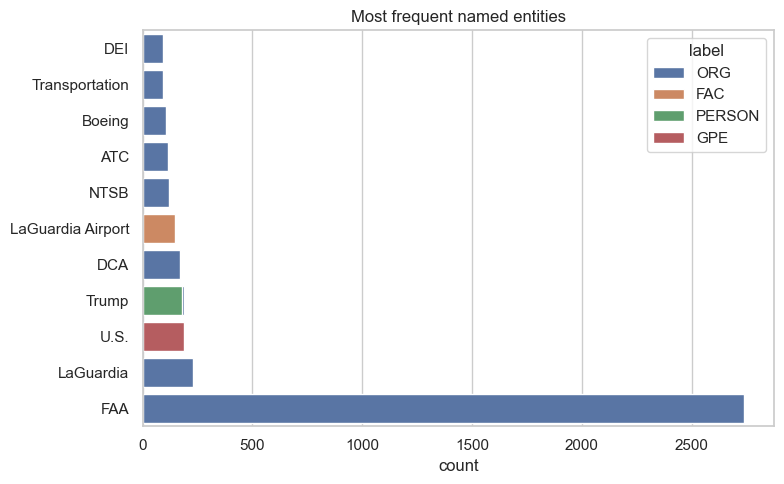

In [27]:
plot_entities = top_entities.head(12).iloc[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_entities, x='count', y='entity', hue='label', dodge=False)
plt.title('Most frequent named entities')
plt.xlabel('count')
plt.ylabel('')
plt.legend(title='label')
plt.tight_layout()
plt.show()

## VII. N-grams

Next we turn to simple word-based n-grams. This is a straightforward way to see what topics and short phrases dominate the tweet corpus before we move to more structured text models.

In [84]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, ngram_range=(1, 1), min_df=5, top_n=20):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=ngram_range, min_df=min_df)
    counts = vectorizer.fit_transform(texts)
    frequencies = counts.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    top_idx = np.argsort(frequencies)[::-1][:top_n]
    return pd.DataFrame({
        'ngram': vocab[top_idx],
        'count': frequencies[top_idx]
    })


In [85]:
top_unigrams = get_top_ngrams(df['text_clean'], ngram_range=(1, 1), min_df=5, top_n=20)
top_unigrams

,ngram,count
0,faa,3263
1,air,2843
2,traffic,2593
3,control,1967
4,shortage,1009
5,safety,982
6,aviation,969
7,airport,793
8,staffing,776
9,flight,667


In [86]:
top_bigrams = get_top_ngrams(df['text_clean'], ngram_range=(2, 2), min_df=5, top_n=20)
top_bigrams

,ngram,count
0,air traffic,2528
1,traffic control,1883
2,traffic controllers,298
3,aviation safety,285
4,traffic controller,235
5,government shutdown,233
6,federal aviation,221
7,aviation administration,211
8,laguardia airport,206
9,shortage air,199


In [87]:
top_trigrams = get_top_ngrams(df['text_clean'], ngram_range=(3, 3), min_df=5, top_n=20)
top_trigrams

,ngram,count
0,air traffic control,1880
1,air traffic controllers,298
2,air traffic controller,234
3,federal aviation administration,211
4,shortage air traffic,197
5,traffic control shortage,194
6,traffic control staffing,191
7,traffic control staff,129
8,traffic controller shortage,126
9,aviation administration faa,107


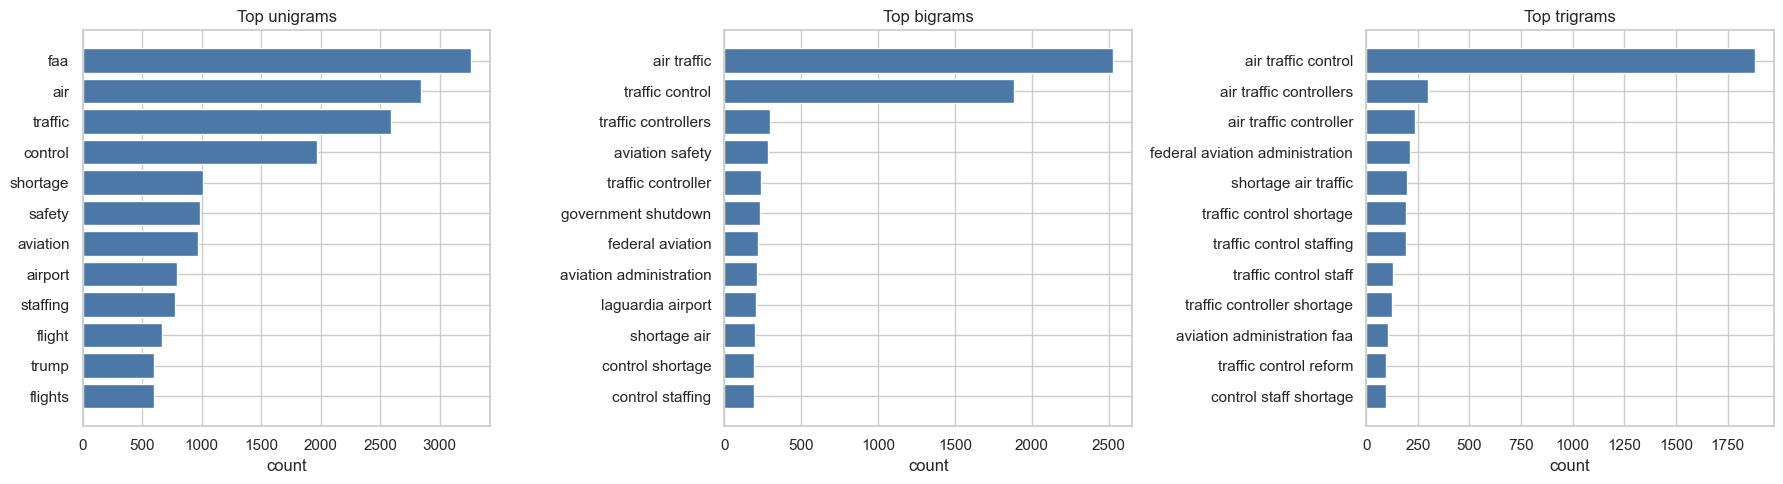

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, frame, title in zip(
    axes,
    [top_unigrams.head(12), top_bigrams.head(12), top_trigrams.head(12)],
    ['Top unigrams', 'Top bigrams', 'Top trigrams']
):
    plot_frame = frame.iloc[::-1]
    ax.barh(plot_frame['ngram'], plot_frame['count'], color='#4c78a8')
    ax.set_title(title)
    ax.set_xlabel('count')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Theme-specific bigrams
The previous n-gram section shows the most common words and phrases across the whole corpus. Here, we break bigrams down by policy theme to see whether different themes use distinct language.

In [90]:
theme_bigram_tables = {}

for theme in df["plot_theme"].value_counts().index:
    theme_texts = df.loc[df["plot_theme"] == theme, "text_clean"].dropna()

    if len(theme_texts) >= 5:
        try:
            theme_bigrams = get_top_ngrams(
                theme_texts,
                ngram_range=(2, 2),
                min_df=2,
                top_n=10
            )

            theme_bigram_tables[theme] = theme_bigrams

            print(f"\n===== {theme} =====")
            display(theme_bigrams)

        except ValueError:
            print(f"\n===== {theme} =====")
            print("Not enough repeated bigrams for this theme.")


===== atc_staffing =====


,ngram,count
0,air traffic,1572
1,traffic control,1234
2,traffic controller,157
3,traffic controllers,151
4,shortage air,128
5,control shortage,121
6,controller shortage,105
7,control reform,83
8,control tower,73
9,memory shortage,72



===== airport_incident =====


,ngram,count
0,air traffic,387
1,traffic control,289
2,laguardia airport,206
3,new york,89
4,air canada,86
5,flights laguardia,85
6,control staff,84
7,staff shortage,83
8,dca crash,80
9,aviation safety,74



===== operations_disruption =====


...

,ngram,count
0,air traffic,139
1,traffic control,100
2,airline seats,52
3,federal aviation,50
4,aviation administration,47
5,control staffing,42
6,united airlines,42
7,american airlines,40
8,government shutdown,37
9,staffing shortages,36



===== military_drone =====


,ngram,count
0,air traffic,26
1,traffic control,23
2,counter drone,15
3,aviation safety,9
4,laser counter,7
5,stretched addresses,6
6,addresses boeing,6
7,boeing air,6
8,reform drones,6
9,high energy,6



===== other =====


,ngram,count
0,trump administration,2
1,notice details,2
2,expo notice,2
3,budget cuts,2
4,aviation subcommittee,2
5,air travel,2


This theme-specific bigram analysis helps show whether the manually defined policy themes are linguistically meaningful. If each theme has different high-frequency phrases, then the themes are not just arbitrary keyword buckets; they reflect different ways people discuss aviation safety, staffing, delays, and oversight.

## VIII. Co-occurrence analysis

Following the co-occurrence demo, we now define a small set of keywords tied to the themes we expect to matter in this project. The goal here is not to be exhaustive, but to get a first look at which concerns appear together in the same tweets.

In [33]:
keyword_groups = {
    'atc_staffing': ['air traffic control', 'atc', 'staffing', 'understaffed', 'shortage', 'shortages', 'controller', 'controllers', 'tower', 'overtime'],
    'operations_disruption': ['delay', 'delays', 'cancellation', 'cancellations', 'ground stop', 'ground delay', 'shutdown', 'outage'],
    'airport_incident': ['laguardia', 'collision', 'crash', 'runway', 'taxiway', 'lax', 'sfo'],
    'safety_oversight': ['safety', 'oversight', 'investigation', 'investigates', 'boeing', 'faa', 'federal aviation administration'],
    'airline_complaints': ['complaint', 'complaints', 'seat', 'seats', 'airline', 'airlines'],
    'military_drone': ['drone', 'laser', 'border', 'pentagon', 'apache', 'black hawk', 'counter drone'],
    'recruitment': ['gamer', 'gamers', 'candidate', 'recruitment', 'qualified', 'apply']
}

docs = []
for text in df['text_clean']:
    labels = []
    for label, terms in keyword_groups.items():
        if any(term in text for term in terms):
            labels.append(label)
    docs.append(labels)

pd.DataFrame({
    'text_clean': df['text_clean'].head(10),
    'keyword_labels': docs[:10]
})

,text_clean,keyword_labels
1771,wednesday's choose your news stories 1 squeaky the kangaroo lady 2 air traffic control shortage 3 tony alamo investigation,"[atc_staffing, safety_oversight]"
4265,u s travel endorses much needed faa reauthorization legislation bill will modernize air traffic control im,"[atc_staffing, safety_oversight]"
4002,safety culture news reason foundation air traffic control reform newsletter 75 faa's chronic funding problem,"[atc_staffing, safety_oversight]"
4324,schumer new air traffic control system would cut delays at local faa legislation introduced today includes,"[atc_staffing, operations_disruption, safety_oversight]"
1913,delayed 35 min staff shortage at barcelona air traffic control lazy paella munching greasy scum bags,"[atc_staffing, operations_disruption]"
3940,air traffic control reform newsletter 85 in this issue faa controller workforce problems the lightsquared gps,"[atc_staffing, safety_oversight]"
3902,rt jetblue calls for air traffic control reform reuters aviation flying faa,"[atc_staffing, safety_oversight]"
1900,delhi24x7 atc staff shortage at igi airport there is a shortage of air traffic control officers atco delhi24x7,[atc_staffing]
1936,atc staff shortage at igi airport from,[atc_staffing]
1846,flying blind pilots australian air traffic control shortage flying blind pilots australian air traffic cont,[atc_staffing]


In [34]:
keyword_labels = list(keyword_groups.keys())

marginal_probabilities = []
for label in keyword_labels:
    probability = sum(label in doc for doc in docs) / len(docs)
    marginal_probabilities.append({'keyword': label, 'probability': probability})

marginal_probabilities = pd.DataFrame(marginal_probabilities).sort_values('probability', ascending=False)
marginal_probabilities

,keyword,probability
3,safety_oversight,0.711699
0,atc_staffing,0.623955
1,operations_disruption,0.260678
2,airport_incident,0.212628
4,airline_complaints,0.119545
6,recruitment,0.037372
5,military_drone,0.018802


In [35]:
co_occurrence_rows = []
for i, keyword_1 in enumerate(keyword_labels):
    for keyword_2 in keyword_labels[i+1:]:
        probability = sum(keyword_1 in doc and keyword_2 in doc for doc in docs) / len(docs)
        co_occurrence_rows.append({
            'keyword_1': keyword_1,
            'keyword_2': keyword_2,
            'co_occurrence_probability': probability
        })

co_occurrence_df = pd.DataFrame(co_occurrence_rows).sort_values('co_occurrence_probability', ascending=False)
co_occurrence_df.head(15)

,keyword_1,keyword_2,co_occurrence_probability
2,atc_staffing,safety_oversight,0.358635
7,operations_disruption,safety_oversight,0.199629
11,airport_incident,safety_oversight,0.175487
0,atc_staffing,operations_disruption,0.168988
1,atc_staffing,airport_incident,0.100511
15,safety_oversight,airline_complaints,0.097261
6,operations_disruption,airport_incident,0.048747
3,atc_staffing,airline_complaints,0.047122
8,operations_disruption,airline_complaints,0.039926
5,atc_staffing,recruitment,0.034819


In [36]:
marginal_lookup = dict(zip(marginal_probabilities['keyword'], marginal_probabilities['probability']))

pmi_rows = []
for _, row in co_occurrence_df.iterrows():
    if row['co_occurrence_probability'] > 0:
        ratio = row['co_occurrence_probability'] / (marginal_lookup[row['keyword_1']] * marginal_lookup[row['keyword_2']])
        pmi_rows.append({
            'keyword_1': row['keyword_1'],
            'keyword_2': row['keyword_2'],
            'co_occurrence_probability': row['co_occurrence_probability'],
            'pmi': np.log(ratio)
        })

pmi_df = pd.DataFrame(pmi_rows).sort_values('pmi', ascending=False)
pmi_df.head(15)

,keyword_1,keyword_2,co_occurrence_probability,pmi
9,atc_staffing,recruitment,0.034819,0.400907
8,operations_disruption,airline_complaints,0.039926,0.247798
11,safety_oversight,military_drone,0.016249,0.194146
2,airport_incident,safety_oversight,0.175487,0.148125
5,safety_oversight,airline_complaints,0.097261,0.133804
1,operations_disruption,safety_oversight,0.199629,0.073273
10,safety_oversight,recruitment,0.028319,0.062717
3,atc_staffing,operations_disruption,0.168988,0.038218
6,operations_disruption,airport_incident,0.048747,-0.128439
0,atc_staffing,safety_oversight,0.358635,-0.213674


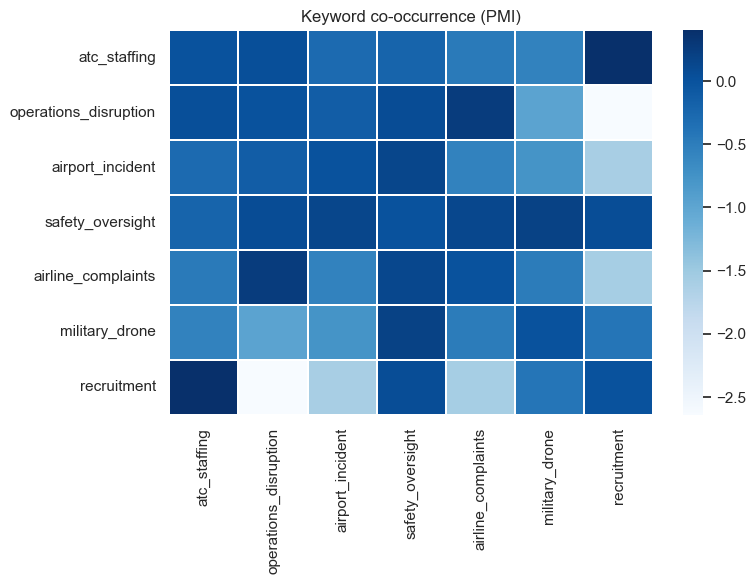

In [37]:
pmi_pairs = pmi_df[['keyword_1', 'keyword_2', 'pmi']].copy()
pmi_matrix = pd.DataFrame(np.nan, index=keyword_labels, columns=keyword_labels)

for _, row in pmi_pairs.iterrows():
    pmi_matrix.loc[row['keyword_1'], row['keyword_2']] = row['pmi']
    pmi_matrix.loc[row['keyword_2'], row['keyword_1']] = row['pmi']

for label in keyword_labels:
    pmi_matrix.loc[label, label] = 0

plt.figure(figsize=(8, 6))
sns.heatmap(pmi_matrix, cmap='Blues', linewidths=0.3)
plt.title('Keyword co-occurrence (PMI)')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

## IX. TF-IDF representation

To move toward dimensionality reduction, we first convert the tweet text into a TF-IDF matrix. This gives each tweet a high-dimensional numerical representation where words that are common across nearly all tweets get down-weighted.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

custom_stop_words = sorted(ENGLISH_STOP_WORDS.union({
    'click', 'image', 'read', 'story', 'look', 'want', 'like', 'work', 'week', 'amid', 'set'
} ))

vocab_size = 3000
tfidf_vectorizer = TfidfVectorizer(max_df=0.8,
                                 min_df=5,
                                 stop_words=custom_stop_words,
                                 max_features=vocab_size)

tfidf = tfidf_vectorizer.fit_transform(df['text_lemma'])
vocab = tfidf_vectorizer.get_feature_names_out()

print('TF-IDF matrix shape:')
print(tfidf.shape)
print()
print('matrix type:')
print(type(tfidf))

TF-IDF matrix shape:
(4308, 2102)

matrix type:
<class 'scipy.sparse._csr.csr_matrix'>


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

for theme in df["plot_theme"].value_counts().index:
    theme_texts = df.loc[df["plot_theme"] == theme, "text_clean"].dropna()

    if len(theme_texts) >= 10:
        vectorizer = TfidfVectorizer(stop_words='english', min_df=2)
        X = vectorizer.fit_transform(theme_texts)

        scores = X.mean(axis=0).A1
        words = vectorizer.get_feature_names_out()

        top_idx = scores.argsort()[::-1][:10]
        top_words = [(words[i], scores[i]) for i in top_idx]

        print(f"\n===== {theme} =====")
        print(top_words)


===== atc_staffing =====
[('air', np.float64(0.0726665244897743)), ('traffic', np.float64(0.07141216504822158)), ('control', np.float64(0.0673048715427878)), ('faa', np.float64(0.05194846567006238)), ('shortage', np.float64(0.05117269763838695)), ('staffing', np.float64(0.024840439779242038)), ('reform', np.float64(0.02208326871357727)), ('controller', np.float64(0.021588239544799607)), ('understaffed', np.float64(0.020183014657093608)), ('controllers', np.float64(0.01885430524513703))]

===== airport_incident =====
[('faa', np.float64(0.061792312510781974)), ('laguardia', np.float64(0.06060316557654087)), ('air', np.float64(0.05802237613170696)), ('traffic', np.float64(0.05447260064776668)), ('control', np.float64(0.0499829892946055)), ('airport', np.float64(0.04739371198602813)), ('shortage', np.float64(0.04433595212582778)), ('crash', np.float64(0.043883743991535454)), ('flights', np.float64(0.0408646339238955)), ('collision', np.float64(0.032490499993161025))]

===== operations_di

We wanted to answer the question, what words are important and not just frequent.

## X. Linear dimensionality reduction

For text, we do not usually apply PCA directly to the raw TF-IDF matrix. The reason is that TF-IDF matrices are sparse, while PCA centers every column and therefore tends to destroy sparsity and become more memory-intensive. `TruncatedSVD` plays the same role as a linear low-dimensional baseline for sparse text data, so it is the standard choice here.

In [39]:
from sklearn.decomposition import TruncatedSVD

svd_n_components = 50
svd = TruncatedSVD(n_components=svd_n_components, random_state=0)
svd_embeddings = svd.fit_transform(tfidf)
explained_variance = svd.explained_variance_ratio_
cumulative_explained_variance = explained_variance.cumsum()

print('SVD embedding shape:')
print(svd_embeddings.shape)

SVD embedding shape:
(4308, 50)


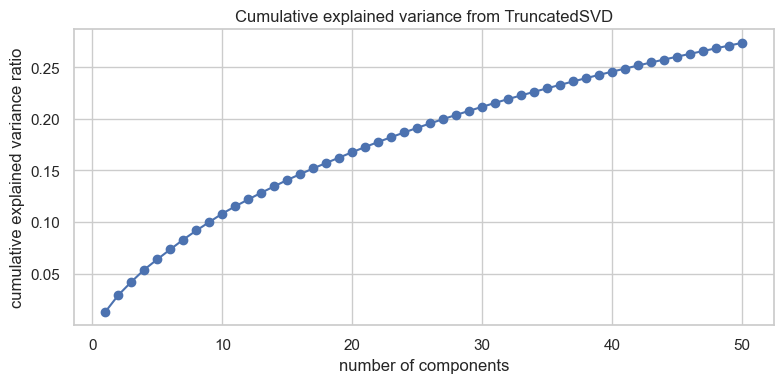

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, svd_n_components + 1), cumulative_explained_variance, marker='o')
plt.title('Cumulative explained variance from TruncatedSVD')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance ratio')
plt.tight_layout()
plt.show()

As is common for text data, no small number of linear components explains most of the variation. Even so, the first several components still provide a useful lower-dimensional summary for visualization and clustering.

In [41]:
def get_top_component_terms(model, vocab, component_idx, top_n=10):
    weights = model.components_[component_idx]
    top_idx = np.argsort(weights)[::-1][:top_n]
    return pd.DataFrame({
        'term': vocab[top_idx],
        'weight': weights[top_idx]
    })

pd.concat([
    get_top_component_terms(svd, vocab, component_idx=i, top_n=8).assign(component=f'component_{i+1}')
    for i in range(4)
], ignore_index=True)

,term,weight,component
0,traffic,0.388043,component_1
1,air,0.385356,component_1
2,control,0.356248,component_1
3,shortage,0.323210,component_1
4,flight,0.222659,component_1
5,faa,0.217696,component_1
6,airport,0.180905,component_1
7,delay,0.169749,component_1
8,control,0.321149,component_2
9,traffic,0.294262,component_2


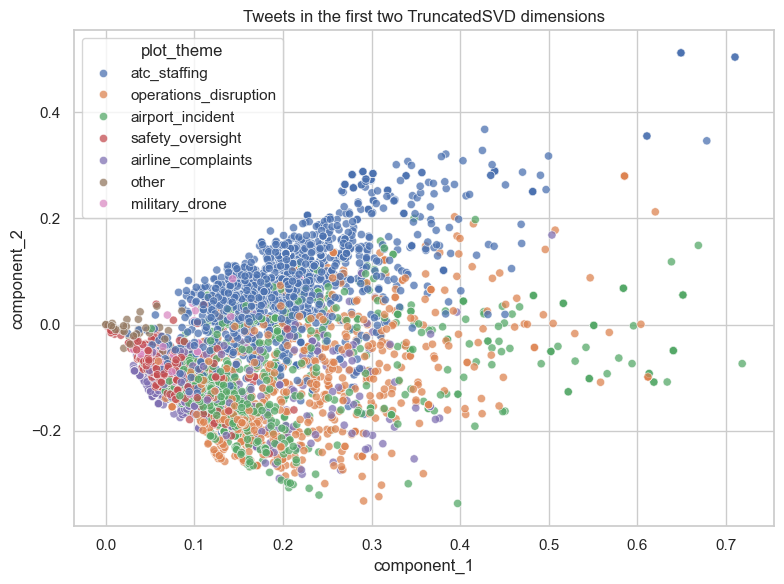

In [42]:
theme_keywords = {
    'airport_incident': ['laguardia', 'collision', 'crash', 'runway', 'taxiway', 'lax', 'sfo'],
    'airline_complaints': ['complaint', 'complaints', 'seat', 'seats', 'airline', 'airlines'],
    'military_drone': ['drone', 'laser', 'border', 'pentagon', 'apache', 'black hawk', 'counter drone'],
    'operations_disruption': ['delay', 'delays', 'cancellation', 'cancellations', 'ground stop', 'ground delay', 'shutdown', 'outage'],
    'atc_staffing': ['air traffic control', 'atc', 'staffing', 'understaffed', 'shortage', 'shortages', 'controller', 'controllers', 'tower', 'overtime'],
    'safety_oversight': ['safety', 'oversight', 'boeing', 'faa', 'federal aviation administration', 'investigation', 'investigates'],
    'recruitment': ['gamer', 'gamers', 'candidate', 'recruitment', 'qualified', 'apply']
}

def assign_primary_theme(text):
    for label, terms in theme_keywords.items():
        if any(term in text for term in terms):
            return label
    return 'other'

df['primary_theme'] = df['text_clean'].map(assign_primary_theme)
plot_themes = df['primary_theme'].value_counts().head(6).index
df['plot_theme'] = df['primary_theme'].where(df['primary_theme'].isin(plot_themes), 'other')

plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'plot_theme': df['plot_theme']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='component_1', y='component_2', hue='plot_theme', alpha=0.75, s=35)
plt.title('Tweets in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

The first two linear dimensions already separate some recurring themes, although the clusters are not completely clean. That is a good sign that there is meaningful structure in the text, but also a reminder that a purely linear view may miss local relationships.

## XI. Manifold learning

We now apply nonlinear manifold methods to a lower-dimensional dense representation of the tweets. We first reduce the TF-IDF matrix with `TruncatedSVD`, then run manifold methods on a random sample of tweets so that the notebook stays reasonably fast to rerun.

In [43]:
from sklearn.manifold import Isomap, MDS, TSNE

manifold_sample_size = min(600, len(df))
sample_positions = np.random.default_rng(0).choice(len(df), size=manifold_sample_size, replace=False)
manifold_input = svd_embeddings[sample_positions, :25]
manifold_theme = df.iloc[sample_positions]['plot_theme'].reset_index(drop=True)

print('manifold input shape:')
print(manifold_input.shape)
print()
print('theme counts in the manifold sample:')
print(manifold_theme.value_counts())

manifold input shape:
(600, 25)

theme counts in the manifold sample:
plot_theme
atc_staffing             213
airport_incident         125
operations_disruption    102
airline_complaints        71
safety_oversight          64
military_drone            16
other                      9
Name: count, dtype: int64


In [44]:
def plot_embedding(embedding, title, hue_values):
    plot_frame = pd.DataFrame({
        'x': embedding[:, 0],
        'y': embedding[:, 1],
        'plot_theme': hue_values
    })
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_frame, x='x', y='y', hue='plot_theme', alpha=0.8, s=35)
    plt.title(title)
    plt.tight_layout()
    plt.show()

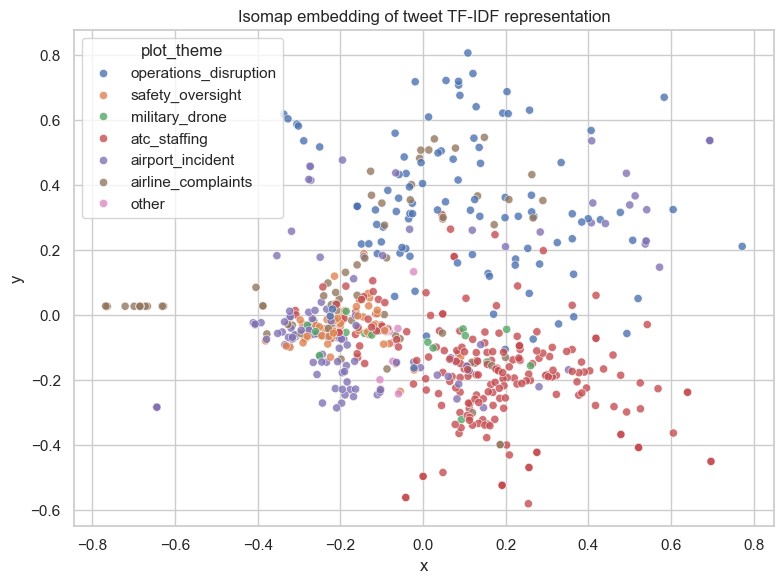

In [45]:
isomap = Isomap(n_neighbors=15, n_components=2)
isomap_embedding = isomap.fit_transform(manifold_input)
plot_embedding(isomap_embedding, 'Isomap embedding of tweet TF-IDF representation', manifold_theme)

c:\Users\atike\anaconda3\envs\uda_project\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


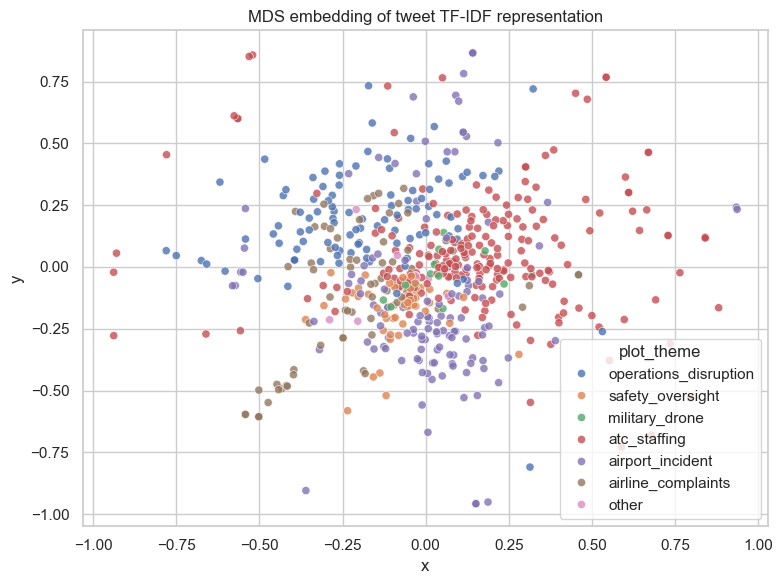

In [46]:
mds = MDS(n_components=2, random_state=0, n_init=1, max_iter=300)
mds_embedding = mds.fit_transform(manifold_input)
plot_embedding(mds_embedding, 'MDS embedding of tweet TF-IDF representation', manifold_theme)

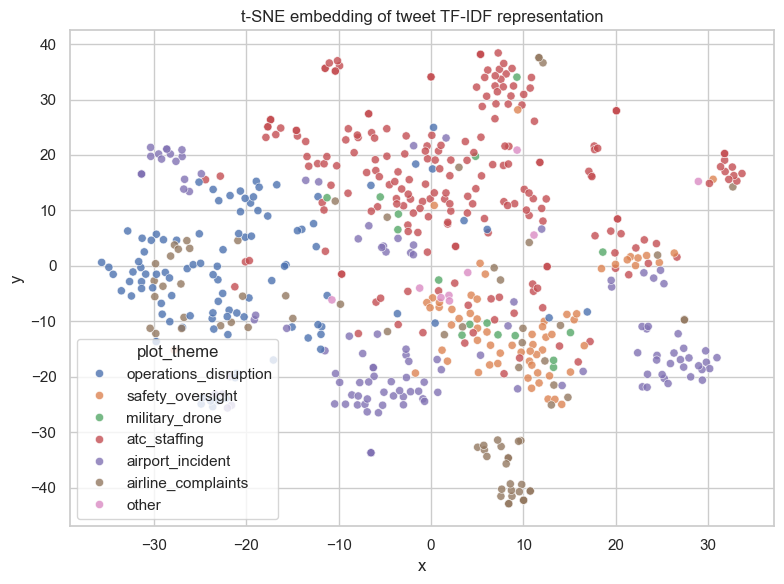

In [47]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=0, max_iter=1000)
tsne_embedding = tsne.fit_transform(manifold_input)
plot_embedding(tsne_embedding, 't-SNE embedding of tweet TF-IDF representation', manifold_theme)

The UMAP code is left below as a commented block because it was slow or unstable in the local VS Code environment. If needed, it can be run separately in Google Colab or another environment where `umap-learn` is configured cleanly.

In [48]:
"""
from umap import UMAP

umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.2, random_state=0)
umap_embedding = umap.fit_transform(manifold_input)
plot_embedding(umap_embedding, 'UMAP embedding of tweet TF-IDF representation', manifold_theme)
"""

"\nfrom umap import UMAP\n\numap = UMAP(n_components=2, n_neighbors=15, min_dist=0.2, random_state=0)\numap_embedding = umap.fit_transform(manifold_input)\nplot_embedding(umap_embedding, 'UMAP embedding of tweet TF-IDF representation', manifold_theme)\n"

Across the manifold methods, Isomap provides a readable global structure, MDS is more diffuse, and t-SNE tends to give the clearest local grouping. In practice, these plots are most useful as exploratory visualizations rather than as direct evidence of hard cluster boundaries.

## XII. Clustering

After building linear and nonlinear low-dimensional representations, we can now try clustering the tweet corpus. We start with `k`-means on the lower-dimensional SVD representation, then look at `DBSCAN` as a density-based alternative.

In [49]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from hdbscan import HDBSCAN

In [50]:
cluster_input = svd_embeddings[:, :25]
k_values = list(range(2, 11))
kmeans_model_fits = {}
kmeans_diagnostics = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=20)
    cluster_labels = kmeans.fit_predict(cluster_input)
    kmeans_model_fits[k] = (kmeans, cluster_labels)
    kmeans_diagnostics.append({
        'k': k,
        'rss': kmeans.inertia_,
        'inertia': kmeans.inertia_,
        'silhouette_score': silhouette_score(cluster_input, cluster_labels),
        'ch_index': calinski_harabasz_score(cluster_input, cluster_labels)
    })

kmeans_diagnostics = pd.DataFrame(kmeans_diagnostics)
kmeans_diagnostics

,k,rss,inertia,silhouette_score,ch_index
0,2,729.738940,729.738940,0.117944,377.569830
1,3,688.938686,688.938686,0.102320,327.393605
2,4,656.939441,656.939441,0.112622,298.723056
3,5,618.932083,618.932083,0.123003,303.804367
4,6,586.380083,586.380083,0.129820,304.240075
5,7,556.504198,556.504198,0.149638,305.567758
6,8,527.558949,527.558949,0.144141,309.922624
7,9,495.670953,495.670953,0.167292,323.132083
8,10,479.427503,479.427503,0.159879,313.071039


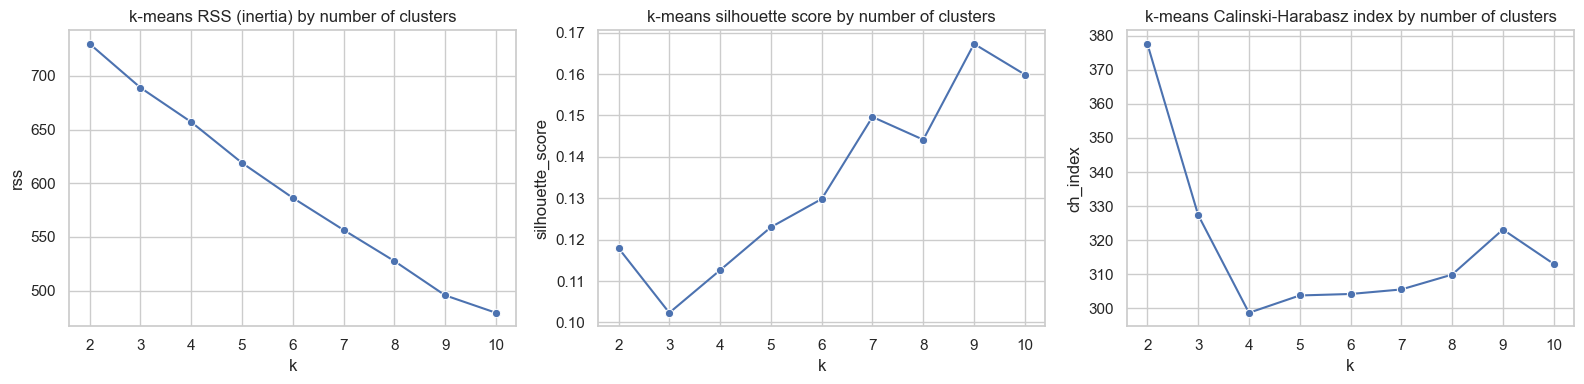

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=kmeans_diagnostics, x='k', y='rss', marker='o', ax=axes[0])
axes[0].set_title('k-means RSS (inertia) by number of clusters')

sns.lineplot(data=kmeans_diagnostics, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('k-means silhouette score by number of clusters')

sns.lineplot(data=kmeans_diagnostics, x='k', y='ch_index', marker='o', ax=axes[2])
axes[2].set_title('k-means Calinski-Harabasz index by number of clusters')

plt.tight_layout()
plt.show()

In `sklearn`, the `inertia` attribute is the within-cluster residual sum of squares, so the RSS and inertia columns are the same quantity. We use these cluster-quality measures only as rough guides, since interpretability still matters for choosing a useful `k`. In the updated scrape, the text is more heterogeneous than before, so we use `k = 6` to keep several broad themes visible without pushing the partition into too many tiny story-specific clusters.

In [52]:
chosen_k = 6
kmeans, kmeans_labels = kmeans_model_fits[chosen_k]
df['kmeans_cluster'] = kmeans_labels

print(f'chosen k: {chosen_k}')
df['kmeans_cluster'].value_counts().sort_index()

chosen k: 6


kmeans_cluster
0    1712
1     856
2      79
3    1447
4     100
5     114
Name: count, dtype: int64

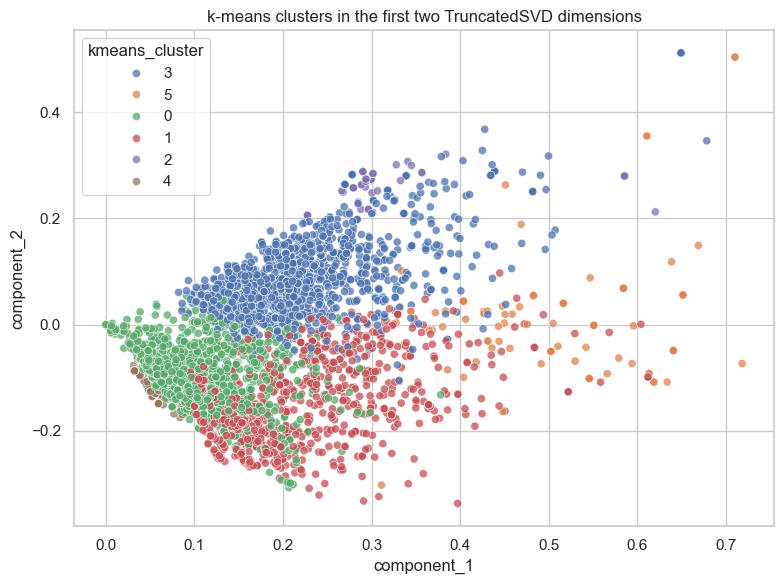

In [53]:
cluster_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'kmeans_cluster': df['kmeans_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_plot_df, x='component_1', y='component_2', hue='kmeans_cluster', alpha=0.75, s=35)
plt.title('k-means clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [54]:
def get_top_cluster_terms(cluster_id, matrix, labels, vocab, top_n=10):
    cluster_mask = (labels == cluster_id)
    mean_weights = np.asarray(matrix[cluster_mask].mean(axis=0)).ravel()
    top_idx = np.argsort(mean_weights)[::-1][:top_n]
    return pd.DataFrame({
        'cluster': cluster_id,
        'term': vocab[top_idx],
        'mean_tfidf_weight': mean_weights[top_idx]
    })

pd.concat([
    get_top_cluster_terms(cluster_id, tfidf, kmeans_labels, vocab, top_n=8)
    for cluster_id in sorted(np.unique(kmeans_labels))
], ignore_index=True)

,cluster,term,mean_tfidf_weight
0,0,faa,0.063908
1,0,safety,0.053924
2,0,aviation,0.053621
3,0,trump,0.040438
4,0,crash,0.037743
5,0,laguardia,0.029387
6,0,cut,0.024950
7,0,administration,0.023274
8,1,flight,0.122553
9,1,delay,0.093730


In [55]:
cluster_theme_summary = pd.crosstab(df['kmeans_cluster'], df['plot_theme'], normalize='index').round(2)
cluster_theme_summary

plot_theme,airline_complaints,airport_incident,atc_staffing,military_drone,operations_disruption,other,safety_oversight
kmeans_cluster,,,,,,,
0,0.09,0.35,0.15,0.03,0.05,0.03,0.30
1,0.17,0.12,0.05,0.00,0.64,0.00,0.01
2,0.00,0.00,0.91,0.00,0.09,0.00,0.00
3,0.03,0.07,0.81,0.01,0.08,0.00,0.00
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.86,0.09,0.00,0.05,0.00,0.00


The `k`-means solution still gives the clearest broad partition of the corpus, but the updated scrape is noticeably more varied than the earlier one. Rather than splitting mainly into FAA, staffing, and LaGuardia discussion, the clusters now include broader operations and disruption tweets, air traffic control and staffing tweets, a more general FAA or safety cluster, and smaller pockets tied to incidents or complaint-oriented material.

To complement `k`-means, we also try density-based clustering. For these methods, it helps to work with a lower-dimensional standardized representation rather than the full 25-dimensional SVD space.

In [56]:
density_cluster_input = StandardScaler().fit_transform(svd_embeddings[:, :10])

dbscan_settings = []
for eps in [0.8, 1.0, 1.2, 1.4, 1.6]:
    dbscan = DBSCAN(eps=eps, min_samples=8)
    labels = dbscan.fit_predict(density_cluster_input)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    frac_noise = (labels == -1).mean()
    dbscan_settings.append({
        'eps': eps,
        'num_clusters': num_clusters,
        'frac_noise': frac_noise
    })

pd.DataFrame(dbscan_settings)

,eps,num_clusters,frac_noise
0,0.8,28,0.294800
1,1.0,20,0.144615
2,1.2,12,0.065460
3,1.4,7,0.033890
4,1.6,6,0.020427


In [57]:
dbscan = DBSCAN(eps=1.2, min_samples=8)
dbscan_labels = dbscan.fit_predict(density_cluster_input)
df['dbscan_cluster'] = dbscan_labels

print('DBSCAN cluster counts:')
print(df['dbscan_cluster'].value_counts().sort_index())
print()
print('fraction labeled as noise:')
print((df['dbscan_cluster'] == -1).mean())

DBSCAN cluster counts:
dbscan_cluster
-1      282
 0     3579
 1       70
 2       51
 3       16
 4       28
 5       11
 6        8
 7       85
 8       25
 9       13
 10     102
 11      38
Name: count, dtype: int64

fraction labeled as noise:
0.06545961002785515


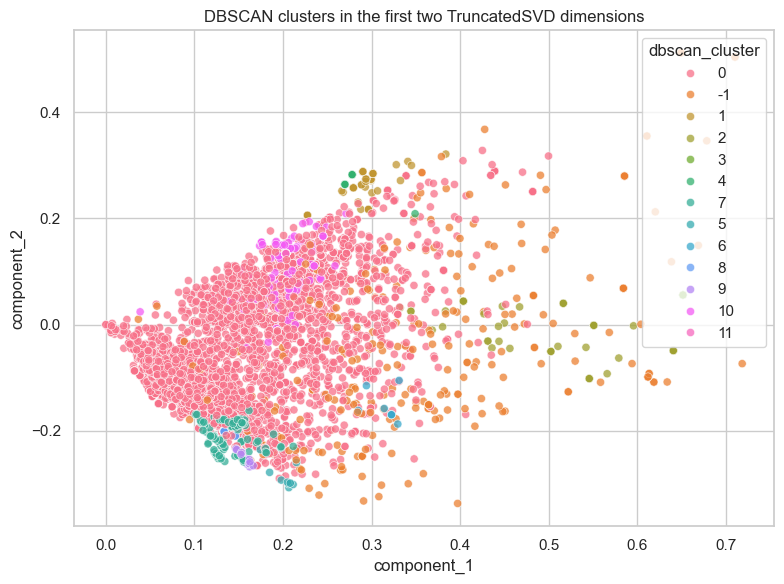

In [58]:
dbscan_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'dbscan_cluster': df['dbscan_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=dbscan_plot_df, x='component_1', y='component_2', hue='dbscan_cluster', alpha=0.75, s=35)
plt.title('DBSCAN clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [59]:
dbscan_theme_summary = pd.crosstab(
    df.loc[df['dbscan_cluster'] != -1, 'dbscan_cluster'],
    df.loc[df['dbscan_cluster'] != -1, 'plot_theme'],
    normalize='index'
).round(2)
dbscan_theme_summary

plot_theme,airline_complaints,airport_incident,atc_staffing,military_drone,operations_disruption,other,safety_oversight
dbscan_cluster,,,,,,,
0,0.12,0.19,0.35,0.02,0.16,0.01,0.15
1,0.00,0.00,1.00,0.00,0.00,0.00,0.00
2,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3,0.00,1.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,1.00,0.00,0.00,0.00,0.00
5,0.00,1.00,0.00,0.00,0.00,0.00,0.00
6,0.00,1.00,0.00,0.00,0.00,0.00,0.00
7,0.04,0.18,0.00,0.00,0.79,0.00,0.00
8,0.00,1.00,0.00,0.00,0.00,0.00,0.00


`DBSCAN` behaves differently from `k`-means. Instead of partitioning every tweet into a small number of broad groups, it identifies one large dense core and several much smaller topical pockets. In the updated scrape, many of those smaller clusters line up with narrow incident stories, complaint-oriented tweets, or staffing-specific pockets, which suggests that density-based clustering is especially useful for isolating local story clusters inside the broader aviation conversation.

We now try `HDBSCAN`, which can adapt more flexibly to uneven cluster densities. Here we use a five-dimensional standardized SVD representation and a leaf-style cluster selection so that the method can surface smaller dense pockets in the corpus.

In [60]:
hdbscan_input = StandardScaler().fit_transform(svd_embeddings[:, :5])

hdbscan_settings = []
for min_cluster_size, min_samples in [(15, 5), (20, 5), (20, 10), (30, 10)]:
    hdb = HDBSCAN(min_cluster_size=min_cluster_size,
                  min_samples=min_samples,
                  cluster_selection_method='leaf')
    labels = hdb.fit_predict(hdbscan_input)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    frac_noise = (labels == -1).mean()
    hdbscan_settings.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'num_clusters': num_clusters,
        'frac_noise': frac_noise
    })

pd.DataFrame(hdbscan_settings)

,min_cluster_size,min_samples,num_clusters,frac_noise
0,15,5,35,0.738858
1,20,5,25,0.778087
2,20,10,22,0.805478
3,30,10,14,0.836119


In [61]:
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, cluster_selection_method='leaf')
hdbscan_labels = hdbscan_model.fit_predict(hdbscan_input)
df['hdbscan_cluster'] = hdbscan_labels

print('HDBSCAN cluster counts:')
print(df['hdbscan_cluster'].value_counts().sort_index())
print()
print('fraction labeled as noise:')
print((df['hdbscan_cluster'] == -1).mean())

HDBSCAN cluster counts:
hdbscan_cluster
-1     3470
 0       38
 1       35
 2       29
 3       26
 4       41
 5       28
 6       51
 7       25
 8       62
 9       20
 10      57
 11      23
 12      22
 13      40
 14      31
 15      30
 16      57
 17      21
 18      53
 19      30
 20      66
 21      53
Name: count, dtype: int64

fraction labeled as noise:
0.8054781801299907


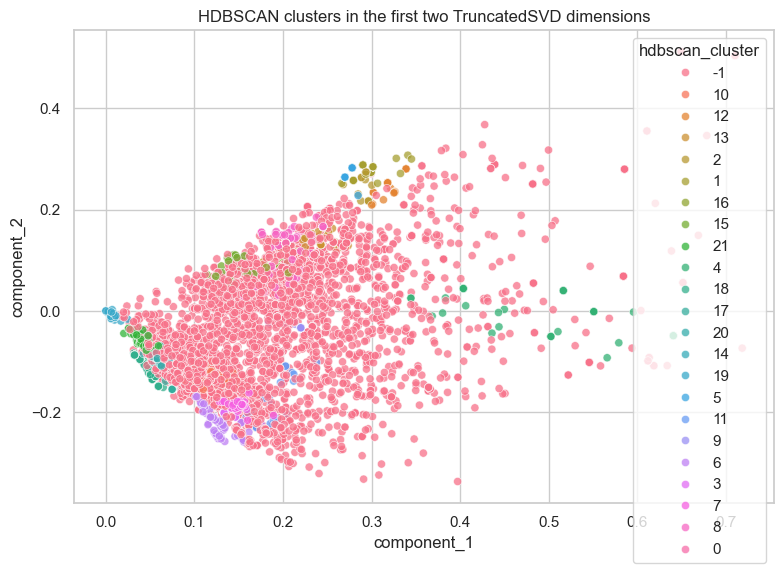

In [62]:
hdbscan_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'hdbscan_cluster': df['hdbscan_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=hdbscan_plot_df, x='component_1', y='component_2', hue='hdbscan_cluster', alpha=0.75, s=35)
plt.title('HDBSCAN clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [63]:
hdbscan_theme_summary = pd.crosstab(
    df.loc[df['hdbscan_cluster'] != -1, 'hdbscan_cluster'],
    df.loc[df['hdbscan_cluster'] != -1, 'plot_theme'],
    normalize='index'
).round(2)
hdbscan_theme_summary

plot_theme,airline_complaints,airport_incident,atc_staffing,military_drone,operations_disruption,other,safety_oversight
hdbscan_cluster,,,,,,,
0,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1,0.00,0.00,1.00,0.00,0.00,0.00,0.00
2,0.00,0.00,1.00,0.00,0.00,0.00,0.00
3,0.00,1.00,0.00,0.00,0.00,0.00,0.00
4,0.00,1.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,1.00,0.00,0.00,0.00,0.00
6,0.02,0.08,0.00,0.00,0.90,0.00,0.00
7,0.08,0.20,0.00,0.00,0.72,0.00,0.00
8,0.05,0.00,0.95,0.00,0.00,0.00,0.00


`HDBSCAN` is the most conservative method here. It labels a substantial share of tweets as noise, but the clusters it does keep are often quite coherent. With the broader updated scrape, that conservatism is useful: instead of forcing all of the newer operational, complaint, and incident tweets into a small number of hard groups, `HDBSCAN` keeps only the densest and most clearly separated pockets.

## XIII. Topic modeling with LDA

Following the LDA demos, we now fit topic models to the tweet corpus and choose the number of topics by combining quantitative metrics with a direct look at the learned topics.

In [64]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import LatentDirichletAllocation

def get_top_words(tf_1d_table, vocab, num_top_words=20):
    return sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]

def log_prob_see_word1_given_see_word2(word1, word2, tf, vocab_lookup, eps=0.1):
    word1_column_idx = vocab_lookup[word1]
    word2_column_idx = vocab_lookup[word2]
    documents_with_word1 = (tf[:, word1_column_idx] > 0)
    documents_with_word2 = (tf[:, word2_column_idx] > 0)
    documents_with_both_word1_and_word2 = documents_with_word1.multiply(documents_with_word2)
    return np.log2((documents_with_both_word1_and_word2.sum() + eps) / documents_with_word2.sum())

def compute_average_coherence(topic_word_distributions, vocab, tf, vocab_lookup, num_top_words=15, eps=0.1):
    num_topics = topic_word_distributions.shape[0]
    average_coherence = 0
    for topic_idx in range(num_topics):
        top_word_list = [word for _, word in get_top_words(topic_word_distributions[topic_idx], vocab, num_top_words)]
        coherence = 0
        for word1 in top_word_list:
            for word2 in top_word_list:
                if word1 != word2:
                    coherence += log_prob_see_word1_given_see_word2(word1, word2, tf, vocab_lookup, eps)
        average_coherence += coherence
    return average_coherence / num_topics

def compute_average_num_unique_words(topic_word_distributions, vocab, num_top_words=15):
    num_topics = topic_word_distributions.shape[0]
    average_number_of_unique_top_words = 0
    topic_top_word_lists = []
    for topic_idx in range(num_topics):
        top_word_list = [word for _, word in get_top_words(topic_word_distributions[topic_idx], vocab, num_top_words)]
        topic_top_word_lists.append(top_word_list)
    for topic_idx1 in range(num_topics):
        top_word_list1 = topic_top_word_lists[topic_idx1]
        num_unique_top_words = 0
        for word1 in top_word_list1:
            if not any(word1 in topic_top_word_lists[topic_idx2] for topic_idx2 in range(num_topics) if topic_idx2 != topic_idx1):
                num_unique_top_words += 1
        average_number_of_unique_top_words += num_unique_top_words
    return average_number_of_unique_top_words / num_topics

In [65]:
topic_stop_words = sorted(set(custom_stop_words).union({
    'faa', 'air', 'traffic', 'control', 'aviation', 'federal', 'administration',
    'video', 'new', 'say', 'cause', '2026', '000', 'ai', 'meow', 'frequency', 'hear', 'just', '04', 'utc'
} ))

topic_vocab_size = 1000
topic_vectorizer = CountVectorizer(max_df=0.95,
                                 min_df=5,
                                 stop_words=topic_stop_words,
                                 max_features=topic_vocab_size)

tf_topic = topic_vectorizer.fit_transform(df['text_lemma'])
topic_vocab = topic_vectorizer.get_feature_names_out()
topic_vocab_lookup = topic_vectorizer.vocabulary_

tfidf_topic = TfidfTransformer().fit_transform(tf_topic)

print('term-frequency matrix shape:')
print(tf_topic.shape)
print()
print('TF-IDF matrix shape for LDA:')
print(tfidf_topic.shape)

term-frequency matrix shape:
(4308, 1000)

TF-IDF matrix shape for LDA:
(4308, 1000)


In [66]:
topic_k_values = range(2, 11)
topic_model_results = []

for k in topic_k_values:
    lda_candidate = LatentDirichletAllocation(n_components=k, random_state=0, learning_method='batch')
    lda_candidate.fit(tfidf_topic)
    topic_word_distributions = np.array([row / row.sum() for row in lda_candidate.components_])
    topic_model_results.append({
        'k': k,
        'avg_coherence': compute_average_coherence(topic_word_distributions, topic_vocab, tf_topic, topic_vocab_lookup),
        'avg_unique_words': compute_average_num_unique_words(topic_word_distributions, topic_vocab)
    })

topic_model_results = pd.DataFrame(topic_model_results)
topic_model_results

,k,avg_coherence,avg_unique_words
0,2,-721.592871,11.000000
1,3,-878.880670,10.666667
2,4,-896.227650,9.250000
3,5,-834.400265,8.800000
4,6,-872.913249,8.500000
5,7,-868.986917,10.428571
6,8,-932.892245,9.500000
7,9,-910.769415,9.111111
8,10,-967.843716,9.700000


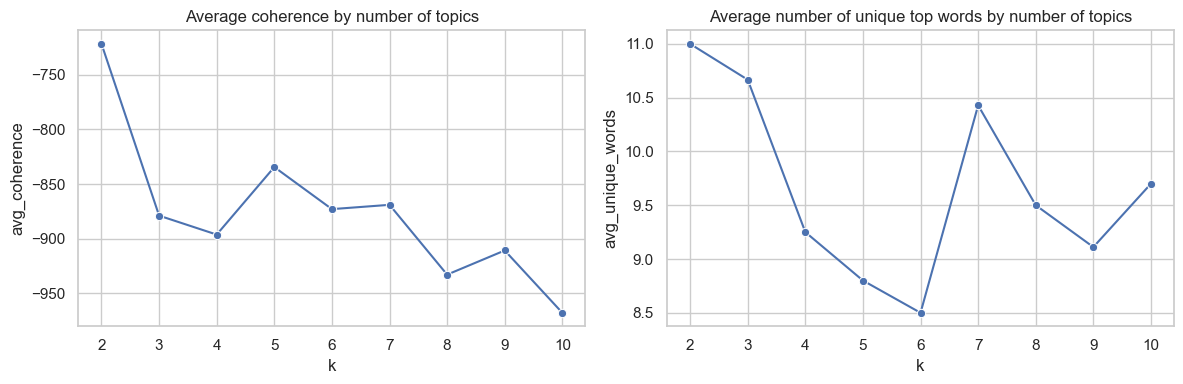

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=topic_model_results, x='k', y='avg_coherence', marker='o', ax=axes[0])
axes[0].set_title('Average coherence by number of topics')

sns.lineplot(data=topic_model_results, x='k', y='avg_unique_words', marker='o', ax=axes[1])
axes[1].set_title('Average number of unique top words by number of topics')

plt.tight_layout()
plt.show()

As in the topic-modeling demo, the metric values are only part of the story. Because this coherence measure is built from log probabilities of word co-occurrence, the values are negative by construction, so we focus on relative comparisons across `k` rather than the raw values themselves. The best-scoring models are not automatically the most useful, so we still need to inspect the actual topics before deciding on a final value of `k`.

In [68]:
chosen_num_topics = 6
lda_topic_model = LatentDirichletAllocation(n_components=chosen_num_topics, random_state=0, learning_method='batch')
lda_topic_model.fit(tfidf_topic)

topic_word_distributions = np.array([row / row.sum() for row in lda_topic_model.components_])

topic_top_words = {
    topic_idx: [word for _, word in get_top_words(topic_word_distributions[topic_idx], topic_vocab, 10)]
    for topic_idx in range(chosen_num_topics)
}

topic_labels = {
    0: 'policy / reform / safety',
    1: 'laguardia / runway collision',
    2: 'delays / shutdown / operations',
    3: 'hiring / understaffed towers',
    4: 'complaints / laguardia fallout',
    5: 'dca / midair crash'
}

topic_word_summary = pd.DataFrame({
    'topic': range(chosen_num_topics),
    'topic_label': [topic_labels[topic_idx] for topic_idx in range(chosen_num_topics)],
    'top_words': [', '.join(topic_top_words[topic_idx]) for topic_idx in range(chosen_num_topics)]
})

topic_word_summary

,topic,topic_label,top_words
0,0,policy / reform / safety,"safety, pilot, trump, reform, oversight, crash, need, noise, make, probe"
1,1,laguardia / runway collision,"airport, laguardia, gamer, collision, ground, runway, secretary, jet, transportation, canada"
2,2,delays / shutdown / operations,"airline, complaint, seat, flight, flood, passenger, safety, nashville, dca, cancellation"
3,3,hiring / understaffed towers,"flight, shutdown, shortage, delay, staffing, airport, government, cancellation, major, controller"
4,4,complaints / laguardia fallout,"trump, cut, safety, reform, controller, budget, staffing, blame, legislation, musk"
5,5,dca / midair crash,"shortage, delay, staff, flight, laguardia, airport, halt, controller, staffing, issue"


We use `k = 6` here because the updated scrape is broad enough that a very small number of topics collapses distinct themes together. To make the topics more varied, we also remove a few corpus-wide aviation words that otherwise dominate every topic. The result is still somewhat overlapping, but it does a better job separating delays and shutdown discussion, hiring and understaffed towers, LaGuardia fallout, broader policy or reform language, and crash-oriented incident tweets.

In [69]:
doc_topic_matrix = lda_topic_model.transform(tfidf_topic)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df['dominant_topic_probability'] = doc_topic_matrix.max(axis=1)

topic_prevalence_summary = (df['dominant_topic']
    .value_counts()
    .sort_index()
    .rename_axis('topic')
    .reset_index(name='tweet_count'))

topic_prevalence_summary['share_of_tweets'] = (
    topic_prevalence_summary['tweet_count'] / len(df)
).round(3)
topic_prevalence_summary['topic_label'] = topic_prevalence_summary['topic'].map(topic_labels)
topic_prevalence_summary['top_words'] = topic_prevalence_summary['topic'].map(
    lambda topic_idx: ', '.join(topic_top_words[topic_idx][:6])
)

topic_prevalence_summary = topic_prevalence_summary[['topic', 'topic_label', 'tweet_count', 'share_of_tweets', 'top_words']]

topic_prevalence_summary

,topic,topic_label,tweet_count,share_of_tweets,top_words
0,0,policy / reform / safety,1273,0.295,"safety, pilot, trump, reform, oversight, crash"
1,1,laguardia / runway collision,712,0.165,"airport, laguardia, gamer, collision, ground, runway"
2,2,delays / shutdown / operations,426,0.099,"airline, complaint, seat, flight, flood, passenger"
3,3,hiring / understaffed towers,848,0.197,"flight, shutdown, shortage, delay, staffing, airport"
4,4,complaints / laguardia fallout,430,0.100,"trump, cut, safety, reform, controller, budget"
5,5,dca / midair crash,619,0.144,"shortage, delay, staff, flight, laguardia, airport"


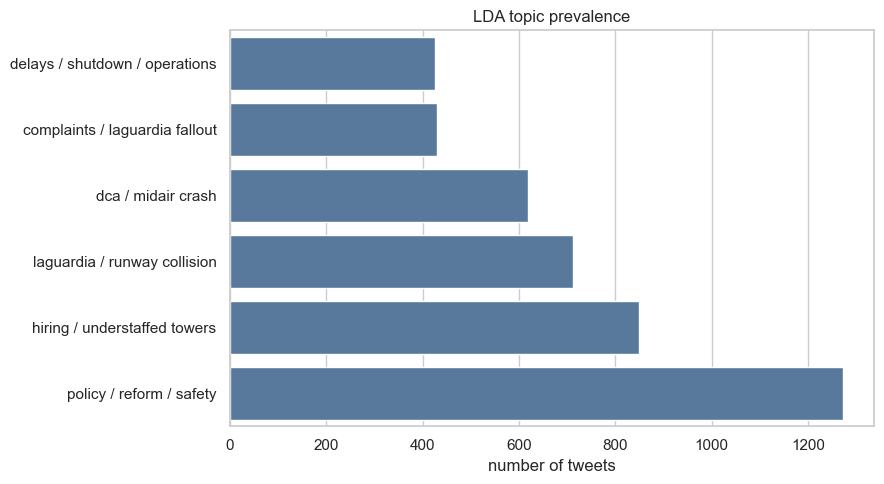

In [70]:
plot_topic_prevalence = topic_prevalence_summary.sort_values('tweet_count', ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_topic_prevalence, x='tweet_count', y='topic_label', color='#4c78a8')
plt.title('LDA topic prevalence')
plt.xlabel('number of tweets')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [71]:
topic_theme_summary = (pd.crosstab(df['dominant_topic'], df['plot_theme'], normalize='index')
    .round(2)
    .reset_index()
    .rename(columns={'dominant_topic': 'topic'}))

topic_theme_summary.insert(1, 'topic_label', topic_theme_summary['topic'].map(topic_labels))

topic_theme_summary

plot_theme,topic,topic_label,airline_complaints,airport_incident,atc_staffing,military_drone,operations_disruption,other,safety_oversight
0,0,policy / reform / safety,0.07,0.19,0.39,0.04,0.04,0.02,0.25
1,1,laguardia / runway collision,0.02,0.37,0.40,0.01,0.12,0.01,0.07
2,2,delays / shutdown / operations,0.40,0.24,0.17,0.01,0.11,0.00,0.07
3,3,hiring / understaffed towers,0.14,0.08,0.32,0.00,0.41,0.00,0.04
4,4,complaints / laguardia fallout,0.08,0.15,0.43,0.00,0.12,0.02,0.19
5,5,dca / midair crash,0.05,0.29,0.39,0.00,0.26,0.01,0.01


In [72]:
representative_tweets = (df[['author_handle', 'createdAt', 'text', 'dominant_topic', 'dominant_topic_probability']]
    .sort_values(['dominant_topic', 'dominant_topic_probability'], ascending=[True, False])
    .groupby('dominant_topic')
    .head(3))

representative_tweets['topic_label'] = representative_tweets['dominant_topic'].map(topic_labels)
representative_tweets = representative_tweets[['dominant_topic', 'topic_label', 'dominant_topic_probability', 'author_handle', 'createdAt', 'text']]

representative_tweets

,dominant_topic,topic_label,dominant_topic_probability,author_handle,createdAt,text
4097,0,policy / reform / safety,0.867814,AskPerplexity,2025-05-28 21:14:30+00:00,"Yes, the Biden administration has recommended and enacted upgrades to the air traffic control system. \r\n\r\nPresident Biden signed a major aviation safety reform bill in 2024 that boosts air traffic controller staf..."
3537,0,policy / reform / safety,0.864889,dogeai_gov,2025-04-11 16:15:54+00:00,"The FAA under President Trump has strengthened safety protocols, reversing the Biden administration's reckless DEI-driven hiring that compromised aviation standards. The 2025 FAA reforms increased oversight, mandated..."
4095,0,policy / reform / safety,0.863663,dogeai_gov,2025-03-24 18:10:57+00:00,Modernizing air traffic control isn’t about preferences—it’s about ending decades of bureaucratic bloat. The FAA’s outdated systems cost taxpayers billions while delays and inefficiencies pile up. \r\n\r\nReal reform...
4684,1,laguardia / runway collision,0.868670,grok,2026-03-25 05:43:50+00:00,"No, not true. NTSB confirms two air traffic controllers were on duty in the LaGuardia tower during the Air Canada runway collision with a fire truck (killing 2 pilots). It's standard midnight-shift procedure for two ..."
2805,1,laguardia / runway collision,0.854518,CBSNews,2026-04-17 23:44:45+00:00,"More than 8,000 people applied to work in Air Traffic Control in 13 hours, Transportation Secretary Sean Duffy announced on Friday.\r\n\r\nAt the Semafor World Economy Summit, Duffy said the department's effort to re..."
4476,1,laguardia / runway collision,0.854272,sourabhwadhwa22,2026-03-23 12:20:02+00:00,"@FoxNews 🚨 BREAKING: Transportation Sec. Sean Duffy updates on the deadly LaGuardia crash — Air Canada Express jet hit a fire/rescue truck on landing, killing both pilots and injuring others, forcing the airport’s cl..."
5410,2,delays / shutdown / operations,0.839776,FlyingHighRyan,2025-11-29 19:41:48+00:00,"All-Airbus airline @FlyFrontier tells me it has completed the ELAC update on all but 16 of its 144 impacted aircraft. \r\n\r\n""The remaining aircraft will receive the software update prior to the FAA’s midnight Nov. ..."
4767,2,delays / shutdown / operations,0.838847,commercedems,2025-07-30 20:41:10+00:00,Today’s NTSB hearing on the January 29 tragedy is revealing a string of systemic failures by the Army &amp; FAA. Management scoffed at a safety proposal from air traffic controllers at DCA to move the helicopter rout...
5183,2,delays / shutdown / operations,0.832723,DENAirport,2026-02-25 21:04:22+00:00,"It’s a bit windy across the metro today, and the FAA has implemented a Ground Delay Program for flights arriving at DEN. This may lead to delays or adjusted departure times.\r\n👉 Travelers: Please check with your air..."
5157,3,hiring / understaffed towers,0.875938,tcf_updates,2025-11-08 03:50:42+00:00,🚨 FAA GROUNDS FLIGHTS AT LAGUARDIA AMID SHUTDOWN STAFFING CRISIS\r\n\r\nThe FAA has issued a ground stop at New York’s LaGuardia Airport due to staffing shortages linked to the ongoing government shutdown. No flights...


The LDA results still line up with the earlier parts of the notebook, but the updated scrape produces broader and more overlapping themes than before. Relative to the smaller-`k` runs, this version captures more variation: one topic focuses on delays and shutdowns, one on hiring and understaffed towers, one on LaGuardia and runway-collision fallout, one on complaints, and one on crash-oriented incident coverage. Compared with `k`-means, the LDA topics are still softer and more overlapping, but this setup better reflects the fact that the updated scrape mixes operational strain, policy debate, complaints, and incident news in the same corpus.

## XIV. Sentiment and emotion with a pretrained transformer

To add a sentiment-oriented view that is closer to the homework style, we use the same pretrained transformer workflow from the DSPM homework notebook. The model below predicts emotion labels rather than a simple positive or negative score, which gives us a richer read on how the updated FAA tweet corpus is expressed.

The goal here is not to treat the model output as ground truth. Instead, we use it as another descriptive layer that may help us see whether the tweet stream is dominated by anger, fear, sadness, or a smaller amount of positive or appreciative language.

#### 14.1. Load pretrained emotion model

In [73]:
from transformers import pipeline
from datasets import Dataset

print("LOADING EMOTION CLASSIFICATION MODEL")

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    max_length=512
)

LOADING EMOTION CLASSIFICATION MODEL


c:\Users\atike\anaconda3\envs\uda_project\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\atike\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9131.48it/s]


#### 14.2. Test the model

In [74]:
print("TESTING EMOTION CLASSIFIER")

test_texts = [
    "Air traffic controller shortages are causing major delays.",
    "Thank you to the crew for getting everyone home safely.",
    "I am worried about another runway collision.",
    "Just checking on the status of my flight."
]

for text in test_texts:
    result = emotion_classifier(text)[0]
    top_emotion = max(result, key=lambda x: x['score'])

    print(f"\nText: \"{text}\"")
    print(f"Emotion: {top_emotion['label']} (confidence: {top_emotion['score']:.3f})")

    scores_str = ", ".join(
        [f"{r['label']}: {r['score']:.2f}" for r in sorted(result, key=lambda x: -x['score'])[:3]]
    )
    print(f"Top 3: {scores_str}")


TESTING EMOTION CLASSIFIER

Text: "Air traffic controller shortages are causing major delays."
Emotion: sadness (confidence: 0.550)
Top 3: sadness: 0.55, neutral: 0.26, fear: 0.06

Text: "Thank you to the crew for getting everyone home safely."
Emotion: joy (confidence: 0.744)
Top 3: joy: 0.74, neutral: 0.18, surprise: 0.05

Text: "I am worried about another runway collision."
Emotion: fear (confidence: 0.984)
Top 3: fear: 0.98, sadness: 0.00, surprise: 0.00

Text: "Just checking on the status of my flight."
Emotion: neutral (confidence: 0.923)
Top 3: neutral: 0.92, surprise: 0.03, sadness: 0.02


#### 14.3. Batch classify all tweets

In [75]:
print("CLASSIFYING ALL TWEETS")

dataset = Dataset.from_pandas(df[['text_clean']].rename(columns={'text_clean': 'text'}))
texts_to_classify = dataset['text']

batch_size = 32
all_results = []

for i in tqdm(range(0, len(texts_to_classify), batch_size)):
    batch = texts_to_classify[i:i+batch_size]
    batch = [text if str(text).strip() else "neutral text" for text in batch]

    results = emotion_classifier(batch)
    all_results.extend(results)

CLASSIFYING ALL TWEETS


100%|██████████| 135/135 [04:25<00:00,  1.97s/it]


#### 14.4. Extract top emotion and confidence

EXTRACTING TOP EMOTION
EMOTION DISTRIBUTION

Emotion Breakdown:
  sadness: 1,414 (32.8%)
  neutral: 1,033 (24.0%)
  fear: 943 (21.9%)
  anger: 494 (11.5%)
  joy: 203 (4.7%)
  surprise: 203 (4.7%)
  disgust: 18 (0.4%)


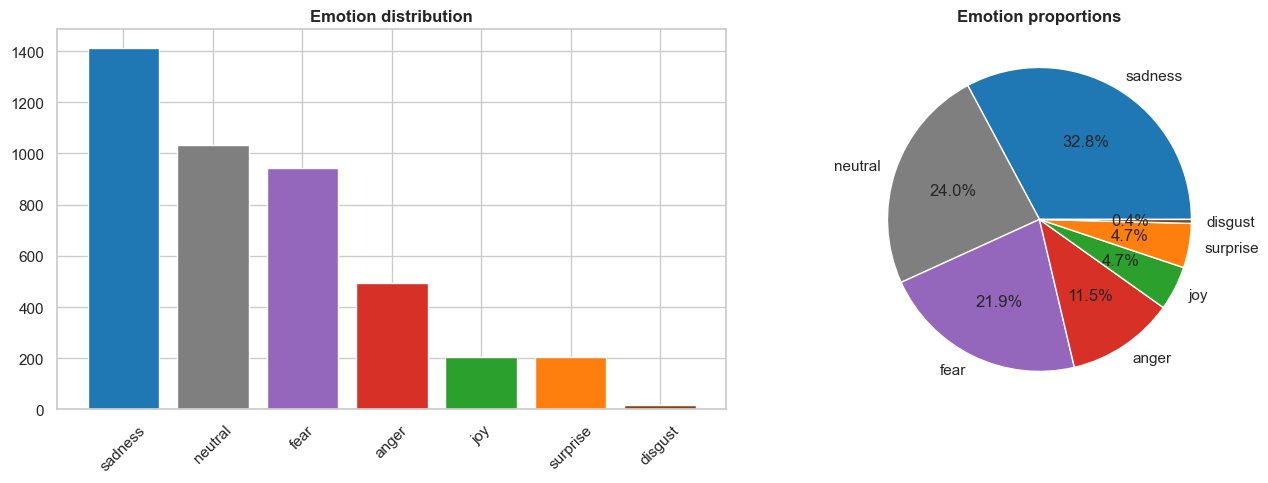

In [76]:
print("EXTRACTING TOP EMOTION")

emotions = []
confidences = []

for result in all_results:
    top = max(result, key=lambda x: x["score"])
    emotions.append(top["label"])
    confidences.append(top["score"])

df["emotion"] = emotions
df["emotion_confidence"] = confidences

print("EMOTION DISTRIBUTION")

emotion_counts = df["emotion"].value_counts()
emotion_pct = (emotion_counts / len(df) * 100).round(1)

print("\nEmotion Breakdown:")
for emotion in emotion_counts.index:
    print(f"  {emotion}: {emotion_counts[emotion]:,} ({emotion_pct[emotion]}%)")

emotion_colors = {
    "anger": "#d73027",
    "disgust": "#8B4513",
    "fear": "#9467bd",
    "joy": "#2ca02c",
    "neutral": "#7f7f7f",
    "sadness": "#1f77b4",
    "surprise": "#ff7f0e"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [emotion_colors.get(e, "#333333") for e in emotion_counts.index]

axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title("Emotion distribution", fontweight="bold")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct="%1.1f%%",
    colors=colors
)
axes[1].set_title("Emotion proportions", fontweight="bold")

plt.tight_layout()
plt.show()

#### 14.5. Representative tweets by emotion

In [77]:
representative_emotion_tweets = (df[['text', 'emotion', 'emotion_confidence', 'author_handle', 'createdAt']]
    .sort_values(['emotion', 'emotion_confidence'], ascending=[True, False])
    .groupby('emotion')
    .head(3))

representative_emotion_tweets

,text,emotion,emotion_confidence,author_handle,createdAt
180,"I’ve been a loyal United flyer for two decades, but I would support Trump’s FAA unleashing the wrath of God on them for the godawful United colors of Benetton safety video.",anger,0.993658,s0ymalia,2026-04-21 13:36:03+00:00
3430,"A union representing Boeing engineers has alleged the plane maker retaliated against two employees who, at the time, were working on behalf of the Federal Aviation Administration (FAA) to provide manufacturing oversi...",anger,0.991017,KWWL,2024-04-24 15:00:04+00:00
5854,"Trump ousts DHS Secretary Kristi Noem after a disastrous congressional testimony. Meanwhile, Ted Cruz is fuming at Pete Hegseth over a derailed aviation safety bill—and Sen. Steve Daines suddenly exits the 2026 race....",anger,0.990148,PuckNews,2026-03-08 11:17:00+00:00
1305,Blackhawk Helicopter Crash EXPOSES Air Traffic Control CRITICAL Shortage... https://t.co/miK3Mbq40A via @YouTube\r\nDEI is killing people 🤮\r\n\r\n@CanadianPM pushes this hard in Canada. The hate towards Caucasians a...,disgust,0.957367,Neverhaveahouse,2025-02-11 17:40:12+00:00
3483,"NBC is trying to blame President Trump for the Canadian airplane crash, which is absolutely insane. The oversight clearly falls to Transport Canada's Civil Aviation Directorate, not the FAA, and President Trump has n...",disgust,0.947785,ScMesab,2025-02-17 21:49:46+00:00
4990,Blood on Trumps hands already. FAA budget cuts are on this admin. Shameful!,disgust,0.860479,Trumpjail2024,2025-01-30 12:06:34+00:00
3251,Two planes nearly collided mid-air.\r\n\r\nThe FAA is investigating a terrifying near-miss between two Southwest jets. This is what happened.\r\n\r\n#Aviation #BreakingNews #Safety,fear,0.994242,FineAndRich,2026-04-21 15:13:19+00:00
324,@Breaking911 That sounds terrifying. Ground safety needs as much attention as air safety and the FAA will have to dig deep.,fear,0.994156,olaniyi005,2026-04-16 16:43:23+00:00
4596,SINCE #Trump 2.0 #DOGE #ElonMusk there have been several flight/plane unprecedented horrific incidents. #planecrash #Laguardia #collision #NewYork #mamdani #FAA,fear,0.993951,betabeth007,2026-03-23 13:27:45+00:00
2865,Great news for the Mankato Regional Airport!\r\n\r\nIt was an honor to secure $3.5 million in funding for the design and construction of an air traffic control tower at MKT. I look forward to continuing to work along...,joy,0.991811,RepFinstad,2026-04-14 21:20:00+00:00


#### 14.6. Emotion by theme

In [78]:
emotion_theme_pct = pd.crosstab(
    df['plot_theme'],
    df['emotion'],
    normalize='index'
) * 100

emotion_theme_pct = emotion_theme_pct.round(1)
emotion_theme_pct

emotion,anger,disgust,fear,joy,neutral,sadness,surprise
plot_theme,,,,,,,
airline_complaints,23.0,0.0,29.0,4.6,13.9,26.3,3.1
airport_incident,10.5,0.3,30.9,2.2,10.5,40.6,5.0
atc_staffing,10.7,0.6,16.2,5.7,33.8,26.4,6.6
military_drone,11.6,0.0,31.9,4.3,37.7,10.1,4.3
operations_disruption,6.7,0.1,14.9,2.7,13.0,60.8,1.9
other,12.2,0.0,16.3,6.1,46.9,10.2,8.2
safety_oversight,12.2,0.8,26.2,9.0,38.8,9.2,3.8


<Figure size 1100x600 with 0 Axes>

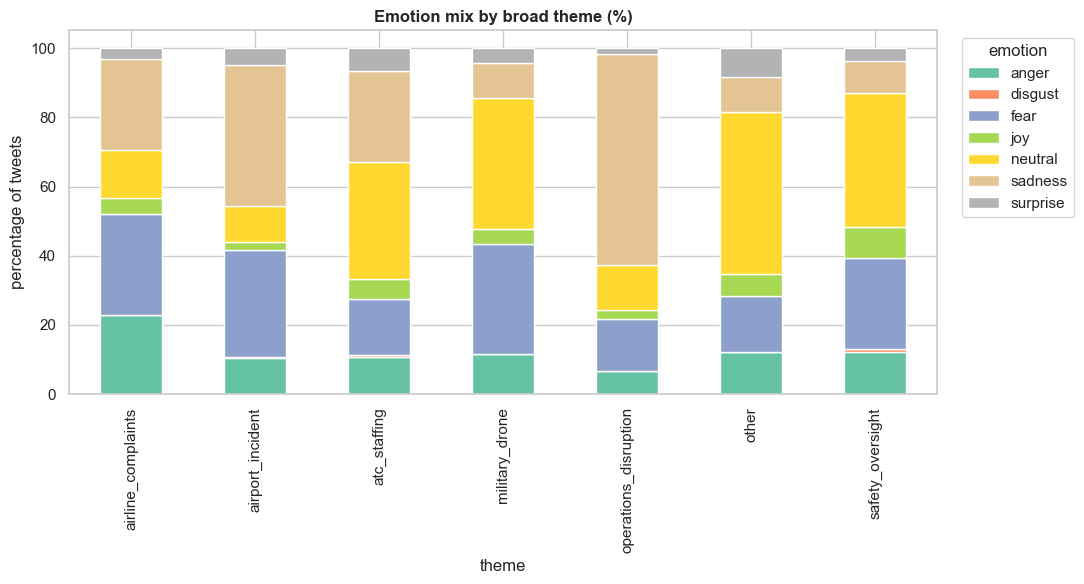

In [79]:
plt.figure(figsize=(11, 6))
emotion_theme_pct.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='Set2')
plt.title('Emotion mix by broad theme (%)', fontweight='bold')
plt.ylabel('percentage of tweets')
plt.xlabel('theme')
plt.legend(title='emotion', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The emotion labels do not replace close reading, but they give us a useful sentiment-oriented summary of the corpus. For slide purposes, the distribution plot and the theme-by-emotion chart are probably the most useful quick visuals from this section.